### Analyze Post-Optimization results for a single run 

**stochastic model with scenario tree for long-term demand uncertainty and using only a subset of weeks each representative year**

# Data reading and setup

In [13]:
# Import python modules
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)

project_root = os.path.abspath(os.path.join(".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [14]:
# Now this works because Python sees `src` as a top-level module
from src import analytics, plotting, utils

In [15]:
import yaml

In [16]:
# Notebook input parameters
SAVE_FIGURES = False
SAVE_TABLES = False
show_plots = False
folder_name = "XXX4weeks_1core___"

In [17]:
FOLDER = os.path.join(
    os.path.dirname(os.getcwd()),
    "runs",
    "single_runs",
    folder_name,
)
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\1_May16_Fri_h23_m07_s45-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_4_4core_bat_and_no_bat\2_May17_Sat_h00_m00_s46-GTSEP_stochastic_v1-128_ES_PT_no_bat"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May22_Thu_h20_m54_s05-GTSEP_stochastic_v2-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_4_sv1_ef05_dc\1_May22_Thu_h15_m32_s51-GTSEP_stochastic_v1-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_4_weeks_efs_ramping\1_May23_Fri_h13_m41_s29-GTSEP_stochastic_v2-128_ES_PT"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_8_weeks_ef05_rf025_bnb\1_May23_Fri_h18_m29_s11-GTSEP_stochastic_v2-128_ES_PT_sv2"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_8_weeks_ef05_rf025_bnb\2_May23_Fri_h19_m46_s36-GTSEP_stochastic_v2-128_ES_PT_sv2_no_bat"
FOLDER = r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\batch_128_sv2_8_weeks_ef05_rf025_bnb_sens_co2price\10_May24_Sat_h02_m19_s08-GTSEP_stochastic_v2-128_ES_PT_sv2_no_bat"
model_info_folder = os.path.join(FOLDER, "model_info")
dual_variables_folder = os.path.join(FOLDER, "dual_variables")
decision_variables_folder = os.path.join(FOLDER, "decision_variables")

In [18]:
RESULTS_FOLDER = os.path.join(FOLDER, "results")
if not os.path.exists(RESULTS_FOLDER):
    os.makedirs(RESULTS_FOLDER)
if SAVE_TABLES:
    tables_folder = os.path.join(RESULTS_FOLDER, "tables")
    if not os.path.exists(tables_folder):
        os.makedirs(tables_folder)
else:
    tables_folder = None
if SAVE_FIGURES:
    figures_folder = os.path.join(RESULTS_FOLDER, "figures")
    if not os.path.exists(figures_folder):
        os.makedirs(figures_folder)
else:
    figures_folder = None

In [19]:
# Color mapping for scenarios (reuse for other plots)
scenario_colors = {
    "NT": "#1f77b4",
    "GA": "#ff7f0e",
    "DE": "#2ca02c",
    "Average": "#7f7f7f",
}

# Define a consistent color palette for cost categories
category_colors = {
    "Invest Gen": "#b20000",  # dark red
    "Invest Bat": "#0072b2",  # blue
    "Invest Tx": "#009e73",  # green
    "Prod Cost": "#f0e442",  # yellow
    "CO₂ Cost": "#d55e00",  # orange
    "Load Shedding Cost": "#800080",  # purple
    "Curtailment Cost": "#56b4e9",  # light blue
}

## Read data

In [20]:
model_info = pd.read_csv(os.path.join(model_info_folder, "model_info.csv"))
config = yaml.safe_load(open(os.path.join(model_info_folder, "config.yaml")))
jsons = utils.read_jsons_from_dir(model_info_folder)

In [21]:
scenarios = jsons["scenarios"]
scenario_probabilities = jsons["scenario_probabilities"]
week_weights = jsons["week_weights"]

In [22]:
data_folder_name = config["data_folder_name"]
VOLL = config["VOLL"]
CC = config["CC"]
CO2_price = config["CO2_price"]
E_limit = config["E_limit"]
p_max_new_branch = config["p_max_new_branch"]
p_min_new_branch = config["p_min_new_branch"]
expansion_factor = config["expansion_factor"]
MS = config["MS"]
model_name = config["model_name"]
MIPGap = config["MIPGap"]
years = config["years"]
r = config["discount_rate"]
representative_period_unit = config["representative_period_unit"]
weeks = config["representative_periods"]
scenario_file = config["scenario_file"]
yearly_discount = config.get("yearly_discount", 10)

In [23]:
input_data_folder = os.path.join(
    os.path.dirname(os.getcwd()), "data", "processed", config["data_folder_name"]
)
input_data = utils.load_multi_year_csv_files_with_week_from_folder(
    years=years, data_folder_path=input_data_folder, yearly_discount=yearly_discount
)
scenario_multiplier = utils.load_scenario_multiplier(scenario_file_name=scenario_file)

**Note:** The input data is such that all data is the same for all years. All the data that is year-dependent has year as index. The only exception is the demand data, which does not have copies for years.

In [24]:
dual_variables = utils.load_csv_files_from_folder_with_scenarios(dual_variables_folder)
decision_varables = utils.load_csv_files_from_folder_with_scenarios(
    decision_variables_folder
)

In [25]:
print("Input data")
for data_type in input_data.keys():
    print(f"{data_type}")
print()
print("Decision variables:")
for decision_variable in decision_varables.keys():
    print(decision_variable)
print()
print("Dual variables:")
for dual_variable in dual_variables.keys():
    print(dual_variable)

Input data
batteries
branches
capacity_factors
generators
generator_costs
hourly_demand
nodes

Decision variables:
battery_capacity
battery_charging
battery_discharging
battery_soc
branch_capacity
curtailment
generation
generator_capacity
load_shedding
power_flow

Dual variables:
battery_charge_new_max_duals
battery_charge_old_duals
battery_discharge_new_max_duals
battery_discharge_old_duals
branch_extension_duals
branch_flow_new_duals_max
branch_flow_new_duals_min
branch_flow_old_duals_max
branch_flow_old_duals_min
emissions_duals
gen_extension_duals
gen_output_new_duals
gen_output_old_duals
load_shedding_duals
power_balance_duals


In [26]:
decision_varables

{'battery_capacity': Empty DataFrame
 Columns: [value]
 Index: [],
 'battery_charging': Empty DataFrame
 Columns: [value]
 Index: [],
 'battery_discharging': Empty DataFrame
 Columns: [value]
 Index: [],
 'battery_soc': Empty DataFrame
 Columns: [value]
 Index: [],
 'branch_capacity':                    value
 branch year             
 88     2025  5000.000000
        2030  5000.000000
        2040     0.000000
        2050     0.000000
 89     2025  3262.447025
 ...                  ...
 107    2050     0.000000
 219    2025     0.000000
        2030     0.000000
        2040     0.000000
        2050     0.000000
 
 [76 rows x 1 columns],
 'curtailment':                                      value
 generator   scenario year week hour       
 ES1 0 CCGT  NT       2025 9    0       0.0
                                1       0.0
                                2       0.0
                                3       0.0
                                4       0.0
 ...                        

In [27]:
# read dataframes
# input data
batteries = input_data["batteries"]
branches = input_data["branches"]
generators = input_data["generators"]
capacity_factors = input_data["capacity_factors"]
generator_costs = input_data["generator_costs"]
hourly_demand = input_data["hourly_demand"]
nodes = input_data["nodes"]
# decision variables
battery_capacity = decision_varables["battery_capacity"]
battery_charging = decision_varables["battery_charging"]
battery_discharging = decision_varables["battery_discharging"]
battery_soc = decision_varables["battery_soc"]
branch_capacity = decision_varables["branch_capacity"]
curtailment = decision_varables["curtailment"]
generation = decision_varables["generation"]
generator_capacity = decision_varables["generator_capacity"]
load_shedding = decision_varables["load_shedding"]
power_flow = decision_varables["power_flow"]

## Generators analysis

### Generators preprocessing

In [28]:
config["expansion_factor"]

0.5

In [29]:
generators["extension_potential"] = generators["p_nom"] * config["expansion_factor"]

In [30]:
# Example usage:
generators = analytics.add_capacity_and_cumulative_metrics(
    generators, generator_capacity
)

In [31]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99017.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99007.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98997.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299110.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,404.400000,539.200000,674.000000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35592.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


### Generator Investment and Capacity Plots 

In [32]:
if SAVE_FIGURES:
    generators_save_folder = os.path.join(figures_folder, "generators")
    if not os.path.exists(generators_save_folder):
        os.makedirs(generators_save_folder)
else:
    generators_save_folder = None

if SAVE_TABLES:
    generators_save_table_folder = os.path.join(tables_folder, "generators")
    if not os.path.exists(generators_save_table_folder):
        os.makedirs(generators_save_table_folder)
else:
    generators_save_table_folder = None

Annual Capacity Investments by Technology


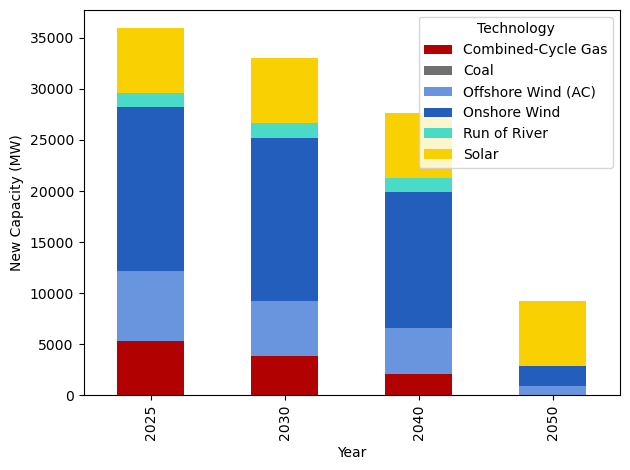

In [119]:
analytics.plot_capacity_investment_by_carrier(generators, generators_save_folder)

Annual Capital Expenditure by Technology


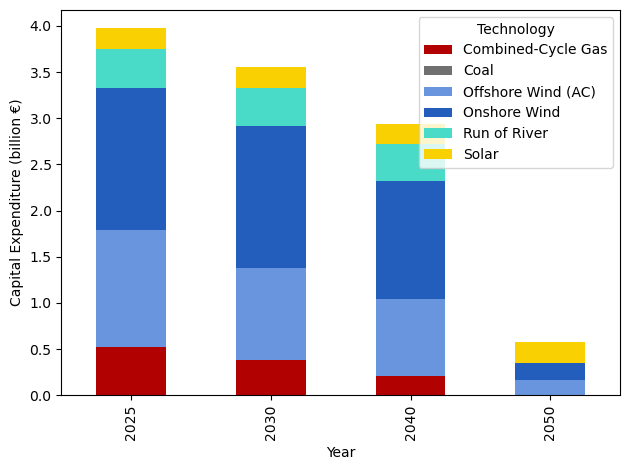

In [34]:
analytics.plot_capacity_spending_by_carrier(generators, generators_save_folder)

Growth in Total Installed Capacity


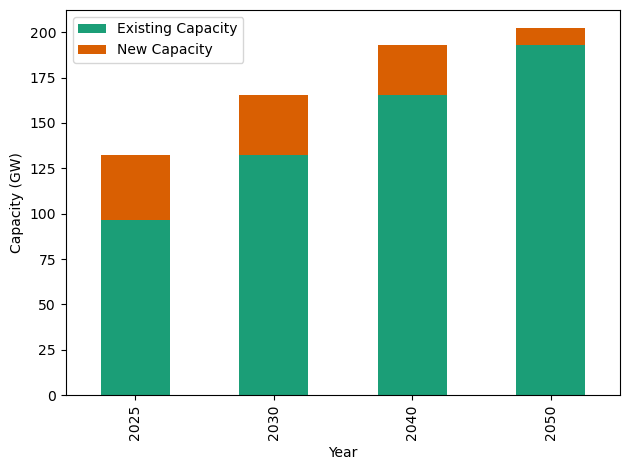

In [35]:
analytics.plot_total_capacity_growth(generators, generators_save_folder)

Extension Potential vs Actual New Capacity by Technology


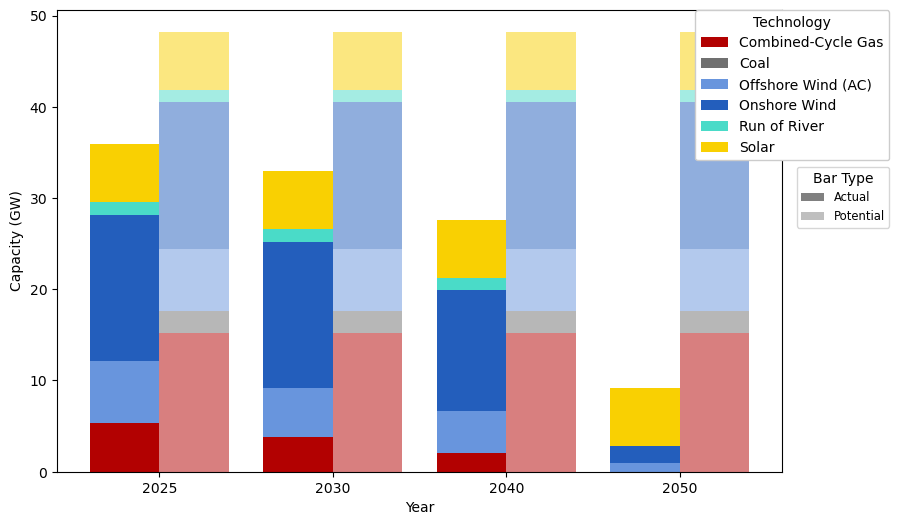

In [36]:
analytics.plot_extension_vs_potential_by_carrier(generators, generators_save_folder)

### Generators Production and Time Series Plots

In [37]:
production_by_carrier_table = analytics.create_energy_production_by_carrier_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    savefolder=generators_save_table_folder,
)
production_by_carrier_table


Annual expected energy production by carrier (scenario-weighted):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar
year,,,,,,
2025,1.255318e+08,5.577534e+04,3.994237e+07,7.238778e+07,1.513015e+07,2.913169e+07
2030,1.036374e+08,7.813758e+03,4.866689e+07,8.942851e+07,2.017354e+07,3.884226e+07
2040,1.194390e+08,1.742619e+05,5.744229e+07,1.083832e+08,2.501130e+07,4.855282e+07
2050,1.249335e+08,1.159558e+06,6.024047e+07,1.133293e+08,2.501130e+07,5.825743e+07


In [38]:
annual_production_table = analytics.make_annual_production_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
annual_production_table

Annual expected energy production by carrier and scenario (MWh):


carrier                CCGT          coal    offwind-ac        onwind  \
year scenario                                                           
2025 NT        1.255318e+08  5.577534e+04  3.994237e+07  7.238778e+07   
2030 NT        1.036374e+08  7.813758e+03  4.866689e+07  8.942851e+07   
2040 DE        4.425788e+07  1.214824e+05  1.946032e+07  3.694431e+07   
     GA        3.329347e+07  6.994984e+03  1.866946e+07  3.488028e+07   
     NT        4.188770e+07  4.578451e+04  1.931251e+07  3.655861e+07   
2050 DE        7.120612e+07  1.123937e+06  3.080212e+07  5.823755e+07   
     GA        5.372734e+07  3.562177e+04  2.943835e+07  5.509171e+07   

carrier                 ror         solar         Total  
year scenario                                            
2025 NT        1.513015e+07  2.913169e+07  2.821796e+08  
2030 NT        2.017354e+07  3.884226e+07  3.007564e+08  
2040 DE        8.337100e+06  1.618427e+07  1.253054e+08  
     GA        8.337100e+06  1.618427e+07  1.113716e+08  
     NT        8.337100e+06  1.618427e+07  1.223260e+08  
2050 DE        1.250565e+07  2.913169e+07  2.030071e+08  
     GA        1.250565e+07  2.912574e+07  1.799244e+08

In [39]:
annual_cost_table = analytics.make_weighted_annual_production_cost_by_year_table(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights,
    carbon_price=CO2_price,
    savefolder=generators_save_table_folder,
)
annual_cost_table

Annual scenario-weighted production cost (incl. CO₂) by technology (EUR):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,8.909422e+09,4.606874e+06,599135.616523,1.085817e+06,0.0,291316.923622,8.916005e+09
2030,7.348452e+09,6.453927e+05,730003.374966,1.341428e+06,0.0,388422.564829,7.351557e+09
2040,8.477436e+09,1.439351e+07,861634.283725,1.625748e+06,0.0,485528.206037,8.494802e+09
2050,8.875484e+09,9.577601e+07,903607.055567,1.699939e+06,0.0,582574.324206,8.974446e+09


In [40]:
weighted_annual_production_by_year = analytics.make_weighted_annual_production_by_year(
    generation,
    generators,
    scenarios,
    scenario_probabilities,
    week_weights=week_weights,
    savefolder=generators_save_table_folder,
)
weighted_annual_production_by_year

Annual scenario-weighted energy production by carrier (MWh):


carrier,CCGT,coal,offwind-ac,onwind,ror,solar,Total
year,,,,,,,
2025,1.255318e+08,5.577534e+04,3.994237e+07,7.238778e+07,1.513015e+07,2.913169e+07,2.821796e+08
2030,1.036374e+08,7.813758e+03,4.866689e+07,8.942851e+07,2.017354e+07,3.884226e+07,3.007564e+08
2040,1.194390e+08,1.742619e+05,5.744229e+07,1.083832e+08,2.501130e+07,4.855282e+07,3.590029e+08
2050,1.249335e+08,1.159558e+06,6.024047e+07,1.133293e+08,2.501130e+07,5.825743e+07,3.829315e+08


Evolution of Annual Energy Production by Technology (averaged across scenarios)


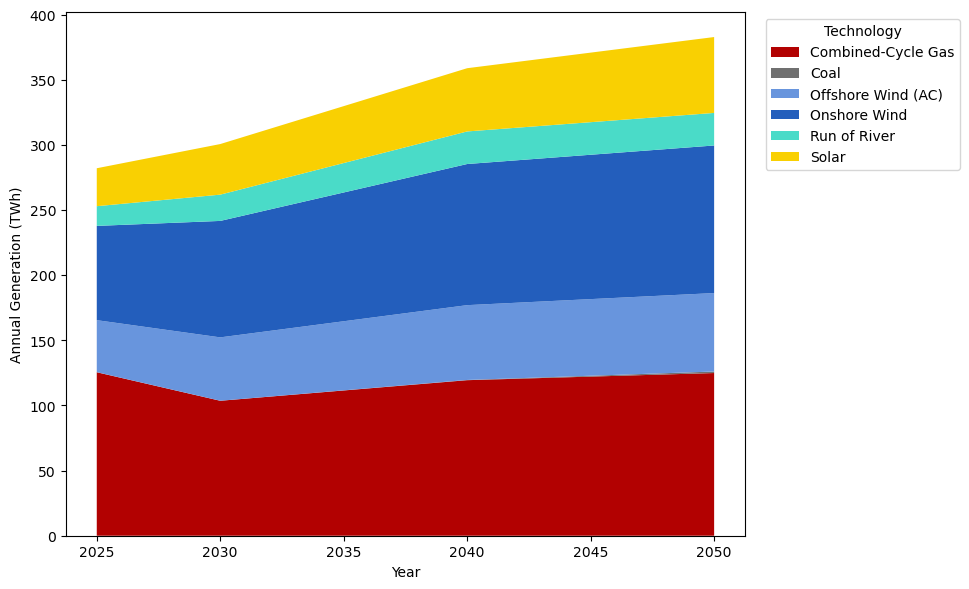

Evolution of Annual Energy Production by Technology (averaged across scenarios)


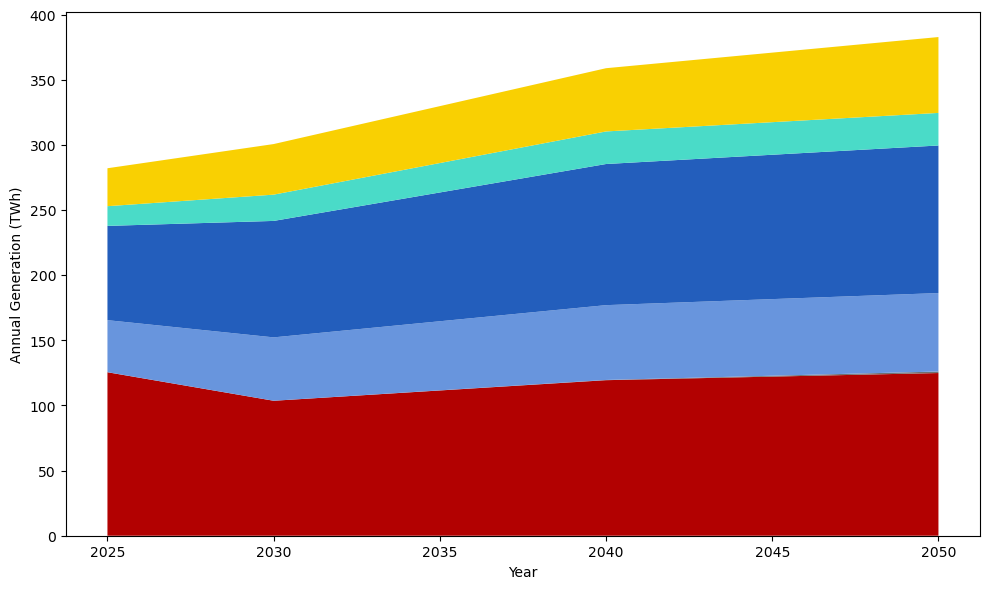

In [41]:
analytics.plot_weighted_production_evolution(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

analytics.plot_weighted_production_evolution_no_legend(
    weighted_annual_production_by_year, generators, savefolder=generators_save_folder
)

Evolution of Annual Production Cost including CO₂ Emissions by Technology


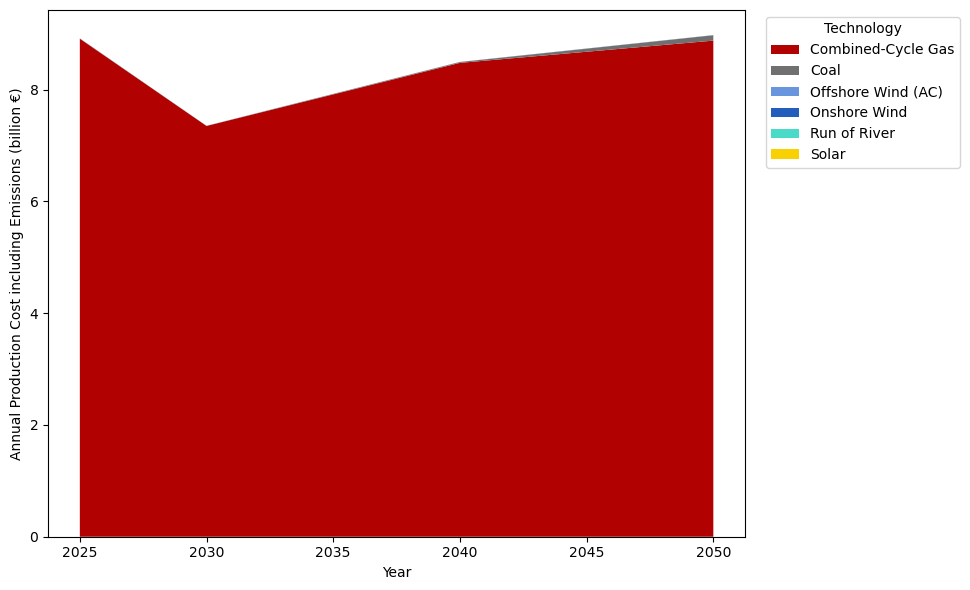

In [42]:
analytics.plot_weighted_production_cost_evolution(
    annual_cost_table, generators, savefolder=generators_save_folder
)

In [43]:
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, generators_save_table_folder
)
yearly_system_cost_table

Yearly system metrics by year and scenario:


production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.821796e+08  2.512532e+07       4.020051e+09     4.895954e+09   
2030 NT        3.007564e+08  2.073013e+07       3.316821e+09     4.034737e+09   
2040 DE        3.759161e+08  2.667864e+07       4.268582e+09     5.193243e+09   
     GA        3.341147e+08  1.998322e+07       3.197315e+09     3.890476e+09   
     NT        3.669779e+08  2.517932e+07       4.028691e+09     4.906100e+09   
2050 DE        4.060141e+08  2.924673e+07       4.679476e+09     5.635269e+09   
     GA        3.598488e+08  2.151516e+07       3.442426e+09     4.191721e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         8.916005e+09  
2030 NT                         7.351557e+09  
2040 DE                         9.461825e+09  
     GA                         7.087791e+09  
     NT                         8.934790e+09  
2050 DE                         1.031475e+10  
     GA                         7.634147e+09

CO₂ Emissions by Year and Scenario


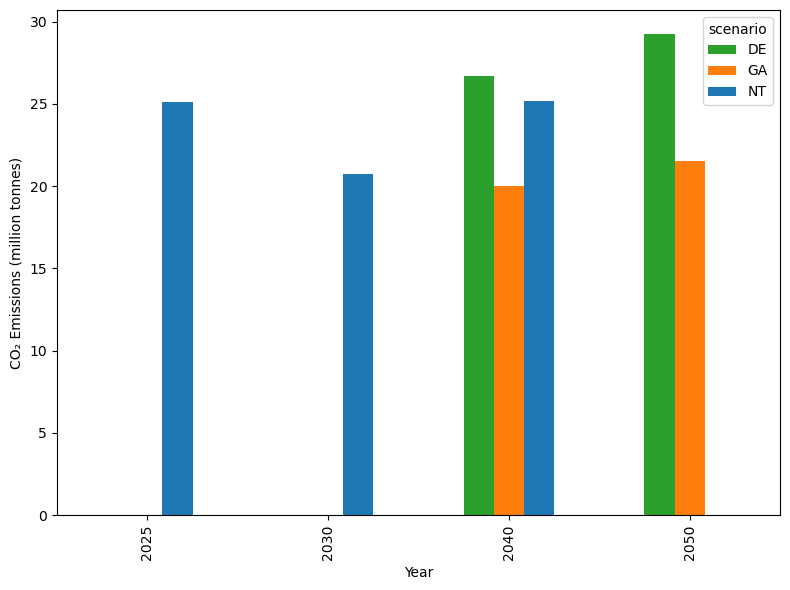

CO₂ Emissions by Year, Scenario, and Average


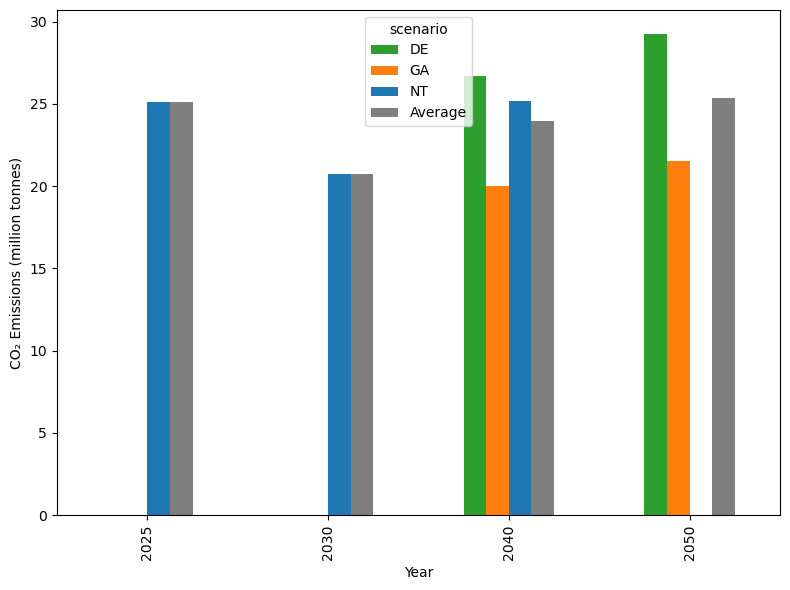

Annual Production by Year, Scenario, and Average


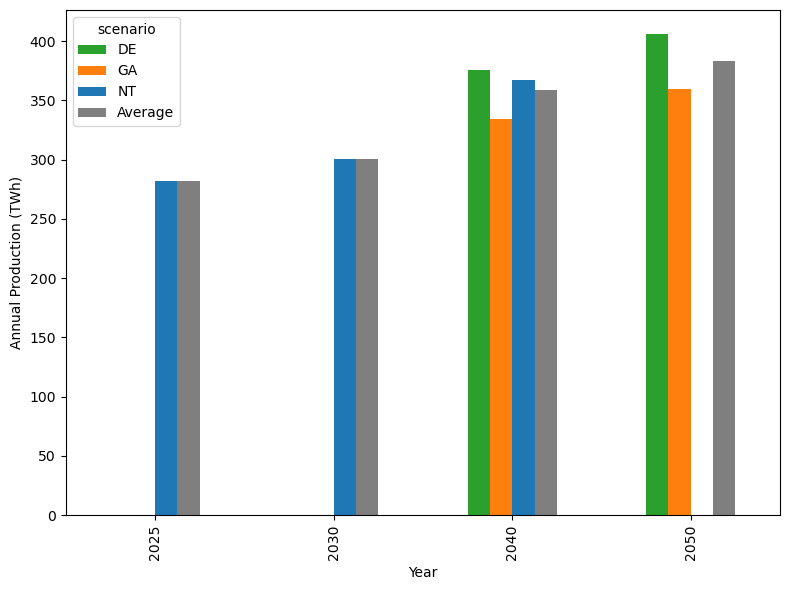

Production Cost by Year, Scenario, and Average


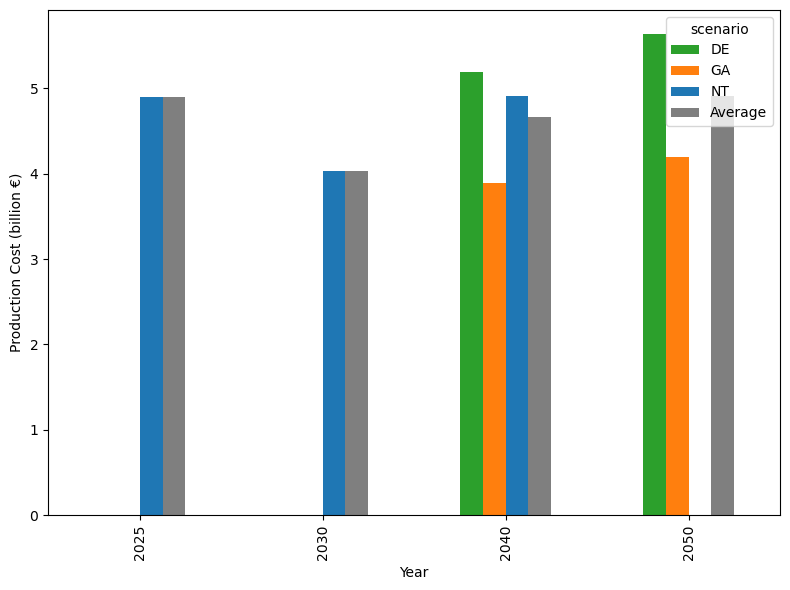

Production Cost w/ Emissions by Year, Scenario, and Average


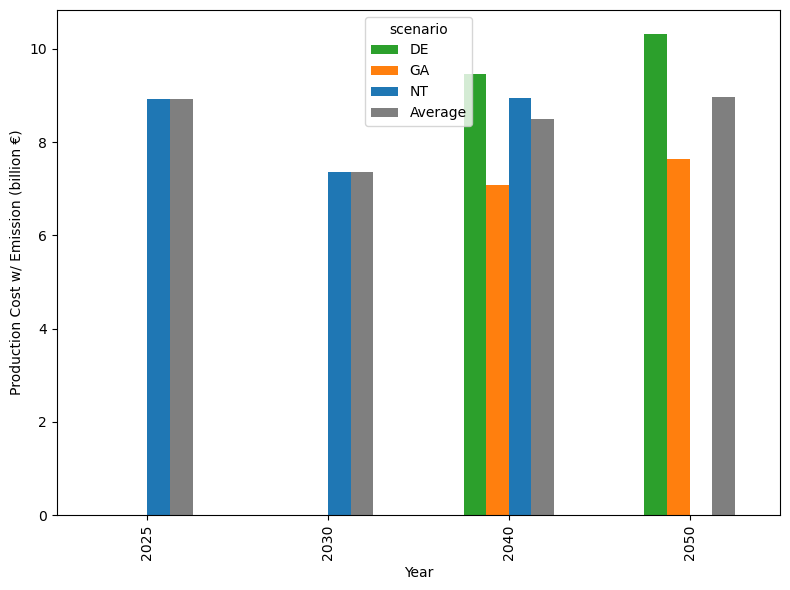

In [44]:
analytics.plot_co2_emissions_by_scenario(
    yearly_system_cost_table, savefolder=generators_save_folder
)
analytics.plot_co2_emissions_by_scenario_avg(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_by_scenario(yearly_system_cost_table, generators_save_folder)
analytics.plot_production_cost_by_scenario(
    yearly_system_cost_table, generators_save_folder
)
analytics.plot_production_cost_with_emission_by_scenario(
    yearly_system_cost_table, generators_save_folder
)

In [45]:
# if figures_folder:
#     generation_curves_folder = os.path.join(figures_folder, "generation_curves")
#     os.makedirs(generation_curves_folder, exist_ok=True)
# else:
#     generation_curves_folder = None

# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# carriers = generators.reset_index()["carrier"].unique()

# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             for carrier in carriers:
#                 analytics.plot_fraction_of_max_generation_by_carrier(
#                     generation,
#                     capacity_factors,
#                     generators,
#                     year,
#                     week,
#                     scen,
#                     carrier,
#                     savefolder=generation_curves_folder,  # or None if you don’t want to save
#                 )

In [46]:
# # loop over combinations
# years = [int(y) for y in scenarios.keys()]
# weeks = [int(w) for w in week_weights.keys()]
# for year in years:
#     for scen in scenarios[str(year)]:
#         for week in weeks:
#             analytics.plot_utilization_time_series_by_carrier(
#                 generation,
#                 capacity_factors,
#                 generators,
#                 year,
#                 week,
#                 scen,
#                 savefolder=tables_folder,
#             )

In [47]:
scenarios

{'2025': ['NT'],
 '2030': ['NT'],
 '2040': ['NT', 'GA', 'DE'],
 '2050': ['GA', 'DE']}

capacity_factors shape: (35040, 51)
cf_weekly shape: (208, 51)
weighted_cf shape: (208, 51)
annual_cf shape: (4, 51)
cap_df shape: (4, 51)
Sample of potential_car: carrier          CCGT          coal    offwind-ac        onwind           ror  \
year                                                                            
2025     3.131496e+08  4.151709e+07  4.240793e+07  7.766080e+07  1.513015e+07   
2030     3.465914e+08  4.151709e+07  5.461067e+07  1.035477e+08  2.017354e+07   
2040     3.649480e+08  4.151709e+07  6.536178e+07  1.265541e+08  2.501130e+07   
2050     3.649480e+08  4.151709e+07  6.841347e+07  1.315628e+08  2.501130e+07   

carrier         solar  
year                   
2025     2.913169e+07  
2030     3.884226e+07  
2040     4.855282e+07  
2050     5.826338e+07  
potential shape: (4, 51)
Sample of capacity_factors:                 ES1 0 offwind-ac  ES1 0 onwind  ES1 0 solar  ES1 1 offwind-ac  \
year week hour                                                         

c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2491: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  actual_car = actual.groupby(gen2car, axis=1).sum()  # (year,scenario)×carrier
c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:2492: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  potential_car = potential.groupby(gen2car, axis=1).sum()  # year×carrier


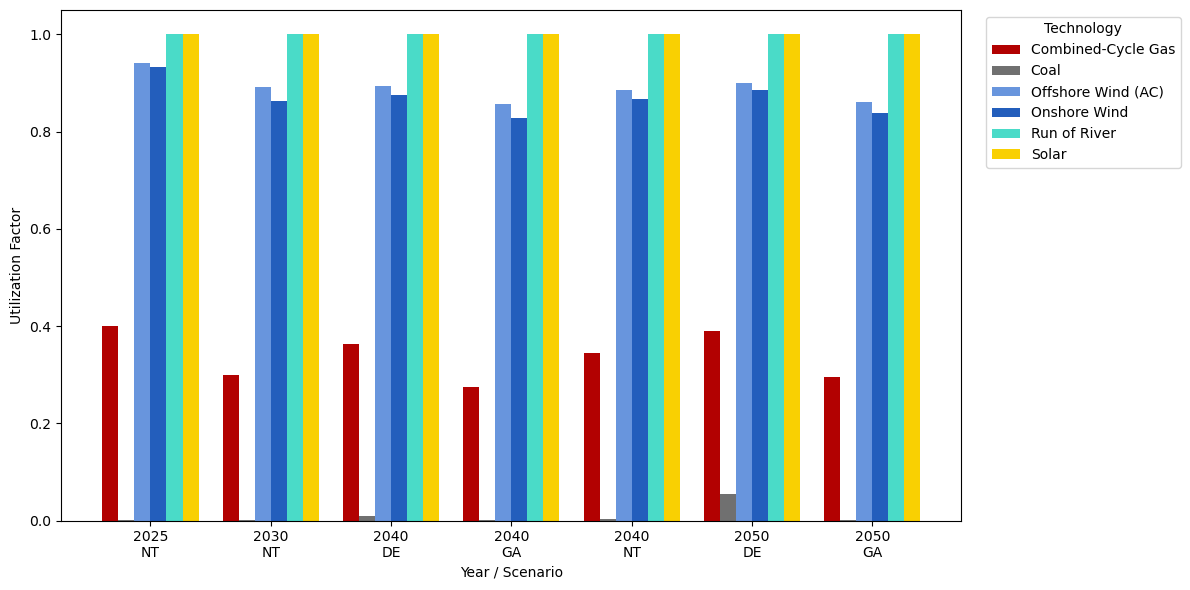

In [48]:
analytics.plot_utilization_hierarchy(
    generation,
    capacity_factors,
    generators,
    week_weights,
    scenarios,
    savefolder=generators_save_folder,
)

In [49]:
summary_table = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=tables_folder,
)

In [50]:
summary_table

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,35930.681544,51,41,3.972938e+09,2.821796e+08,2.512532e+07,4.020051e+09,4.895954e+09,8.916005e+09,1.288894e+10
2030,48228.204285,32977.401815,51,35,3.555738e+09,3.007564e+08,2.073013e+07,3.316821e+09,4.034737e+09,7.351557e+09,1.090730e+10
2040,48228.204285,27597.218960,51,27,2.941959e+09,3.590029e+08,2.394706e+07,3.831529e+09,4.663273e+09,8.494802e+09,1.143676e+10
2050,48228.204285,9179.564159,51,13,5.774627e+08,3.829315e+08,2.538094e+07,4.060951e+09,4.913495e+09,8.974446e+09,9.551909e+09


In [51]:
summary_by_carrier_table = analytics.make_system_summary_table_by_carrier(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    tables_folder,
)
summary_by_carrier_table

potential_capacity  new_capacity  number_possible_buildouts  \
year carrier                                                                   
2025 CCGT              15225.166000   5297.340000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   6867.326111                          9   
     onwind            16019.751672  16019.751672                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   6353.509637                         11   
2030 CCGT              15225.166000   3817.557543                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   5393.828839                          9   
     onwind            16019.751672  16019.751672                         11   
     ror                1392.754124   1392.754124                          4   
     solar              6353.509637   6353.509637                         11   
2040 CCGT              15225.166000   2095.500000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111   4518.409835                          9   
     onwind            16019.751672  13310.549489                         11   
     ror                1392.754124   1319.250000                          4   
     solar              6353.509637   6353.509637                         11   
2050 CCGT              15225.166000      0.000000                         11   
     coal               2369.696741      0.000000                          5   
     offwind-ac         6867.326111    909.545924                          9   
     onwind            16019.751672   1916.508598                         11   
     ror                1392.754124      0.000000                          4   
     solar              6353.509637   6353.509637                         11   

                 number_actual_buildouts  cost_of_buildout  total_production  \
year carrier                                                                   
2025 CCGT                              6      5.245836e+08      1.255318e+08   
     coal                              0      0.000000e+00      5.577534e+04   
     offwind-ac                        9      1.266256e+09      3.994237e+07   
     onwind                           11      1.539272e+09      7.238778e+07   
     ror                               4      4.166288e+08      1.513015e+07   
     solar                            11      2.261981e+08      2.913169e+07   
2030 CCGT                              4      3.780059e+08      1.036374e+08   
     coal                              0      0.000000e+00      7.813758e+03   
     offwind-ac                        5      9.958712e+08      4.866689e+07   
     onwind                           11      1.539112e+09      8.942851e+07   
     ror                               4      4.166149e+08      2.017354e+07   
     solar                            11      2.261346e+08      3.884226e+07   
2040 CCGT                              3      2.074707e+08      1.194390e+08   
     coal                              0      0.000000e+00      1.742619e+05   
     offwind-ac                        3      8.351132e+08      5.744229e+07   
     onwind                            8      1.278690e+09      1.083832e+08   
     ror                               2      3.946144e+08      2.501130e+07   
     solar                            11      2.260710e+08      4.855282e+07   
2050 CCGT                              0      0.000000e+00      1.249335e+08   
     coal                              0      0.000000e+00      1.159558e+06   
     offwind-ac                        1      1.673633e+08      6.024047e+07   
     onwind                            1      1.840919e+08      1.133293e+08   
     ror        

## Transmission Lines

In [52]:
# Preprocessing
if "extended_by" in branches.columns:
    branches.drop(columns=["extended_by"], inplace=True)
if "branch" in branch_capacity.index.names:
    branch_capacity = branch_capacity.rename_axis(index={"branch": "line"})
if "branch" in power_flow.index.names:
    power_flow = power_flow.rename_axis(index={"branch": "line"})
branches["extension_potential"] = p_max_new_branch

In [53]:
if SAVE_FIGURES:
    branches_save_folder = os.path.join(figures_folder, "branches")
    if not os.path.exists(branches_save_folder):
        os.makedirs(branches_save_folder)
else:
    branches_save_folder = None
if SAVE_TABLES:
    branches_save_table_folder = os.path.join(tables_folder, "branches")
    if not os.path.exists(branches_save_table_folder):
        os.makedirs(branches_save_table_folder)
else:
    branches_save_table_folder = None

In [54]:
branches = analytics.extend_branches_table(branches, branch_capacity)

In [55]:
branches["capital_cost"]

year  line
2025  88      23102.962586
2030  88      23092.962586
2040  88      23082.962586
2050  88      23072.962586
2025  89      11729.199350
                  ...     
2050  107     22031.025373
2025  219     14480.882016
2030  219     14470.882016
2040  219     14460.882016
2050  219     14450.882016
Name: capital_cost, Length: 76, dtype: float64

Annual New Branch Capacity Additions


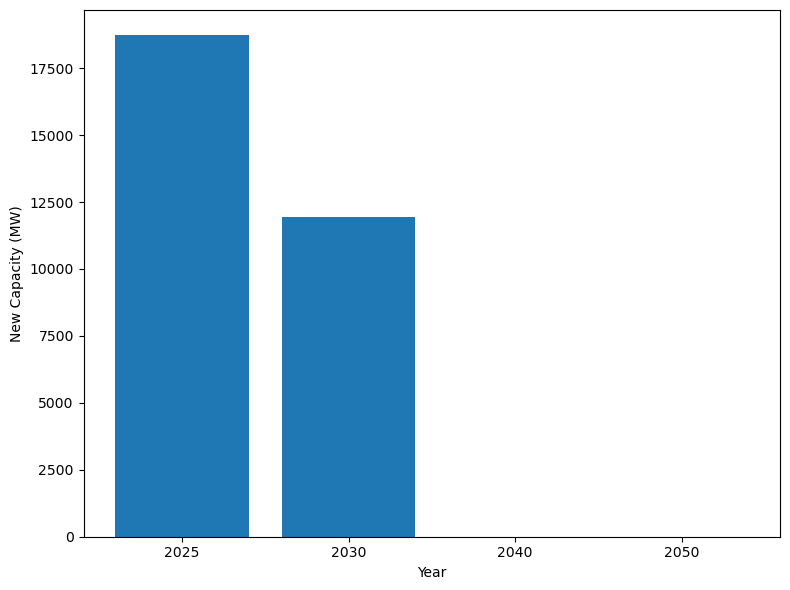

In [56]:
analytics.plot_branch_new_capacity(branches, savefolder=branches_save_folder)

In [57]:
branch_buildout_summary = analytics.make_branch_buildout_summary(
    branches, savefolder=branches_save_table_folder
)


branch_buildout_summary

Branch buildout summary by year:


,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,18733.823892,19,5,3.192813e+08
2030,95000,11935.560098,19,3,2.037555e+08
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [58]:
branch_flow_table_per_line = analytics.make_branch_flow_metrics(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_table_per_line

utilization_rate  congestion_rate
line scenario year                                   
88   DE       2040          0.984113         0.871280
              2050          0.979429         0.825893
     GA       2040          0.992650         0.946429
              2050          0.988326         0.893601
     NT       2025          1.000000         1.000000
...                              ...              ...
219  GA       2040          0.875739         0.430060
              2050          0.869385         0.416667
     NT       2025          0.706496         0.040923
              2030          0.838549         0.232887
              2040          0.884426         0.443452

[133 rows x 2 columns]

In [59]:
branch_flow_summary = analytics.make_aggregate_branch_flow_summary(
    power_flow, branches, week_weights, savefolder=branches_save_table_folder
)
branch_flow_summary

utilization_rate  congestion_rate
year scenario                                   
2025 NT                0.678255         0.495614
2030 NT                0.748016         0.541393
2040 DE                0.749105         0.548246
     GA                0.751530         0.550047
     NT                0.749797         0.548716
2050 DE                0.747503         0.547502
     GA                0.750339         0.548990

Transmission line investments in 2025:


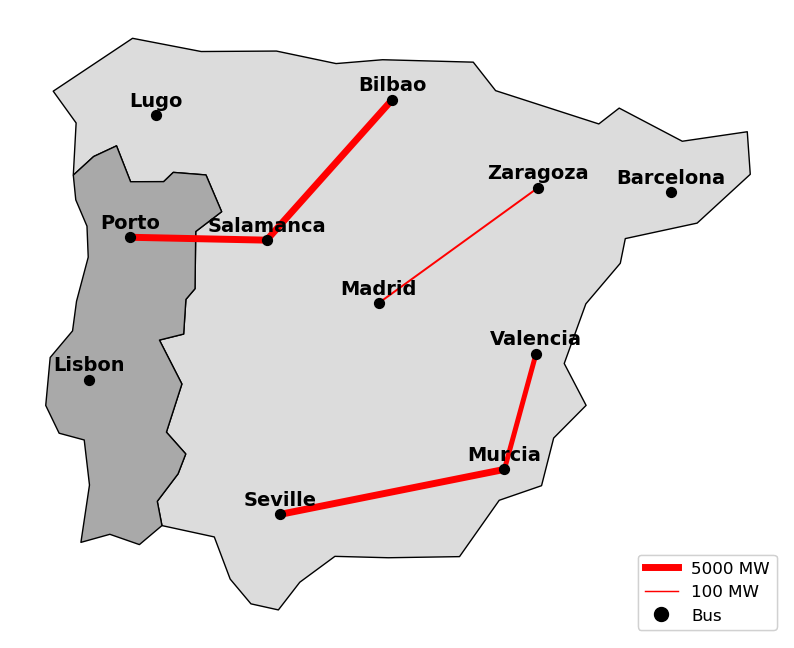

Plotting grid with new branches in year 2025
Transmission line investments in 2030:


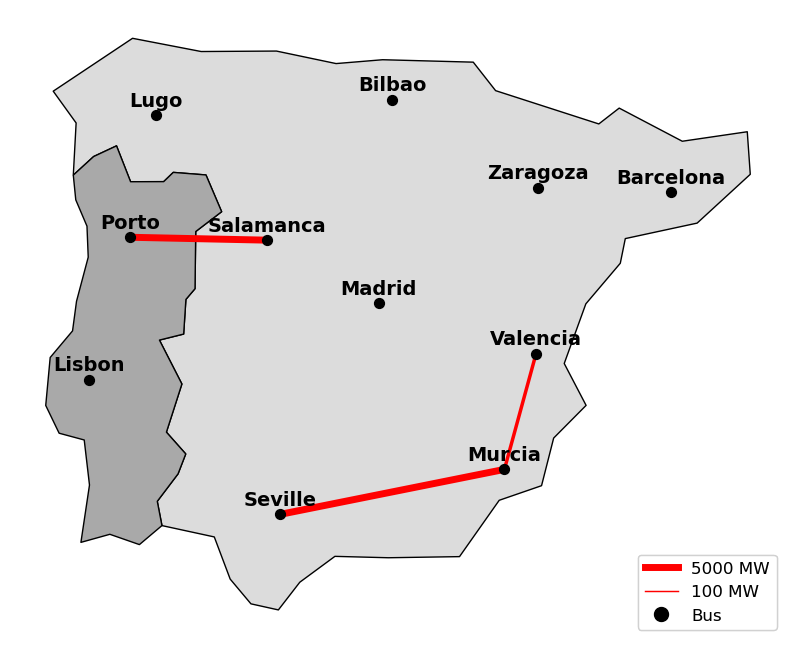

Plotting grid with new branches in year 2030


In [60]:
analytics.plot_new_branches_for_years_with_investments(
    branches, branch_capacity, nodes, savefolder=branches_save_folder
)

## Batteries

In [61]:
if SAVE_FIGURES:
    batteries_save_folder = os.path.join(figures_folder, "batteries")
    if not os.path.exists(batteries_save_folder):
        os.makedirs(batteries_save_folder)
else:
    batteries_save_folder = None
if SAVE_TABLES:
    batteries_save_table_folder = os.path.join(tables_folder, "batteries")
    if not os.path.exists(batteries_save_table_folder):
        os.makedirs(batteries_save_table_folder)
else:
    batteries_save_table_folder = None

In [62]:
if len(batteries) > 0:
    batteries = analytics.extend_batteries_table(batteries.copy(), battery_capacity)
    analytics.plot_battery_investment_by_year(
        batteries, savefolder=batteries_save_folder
    )
    analytics.plot_battery_investment_cost_by_year(
        batteries, savefolder=batteries_save_folder
    )
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        batteries_save_table_folder,
    )
    analytics.plot_cycles_per_scenario_with_average(
        battery_discharging,
        week_weights,
        reference_cycle_mwh=400 * (0.8),
        savefolder=batteries_save_folder,
    )
    battery_summary

Annual Curtailment by Year and Scenario


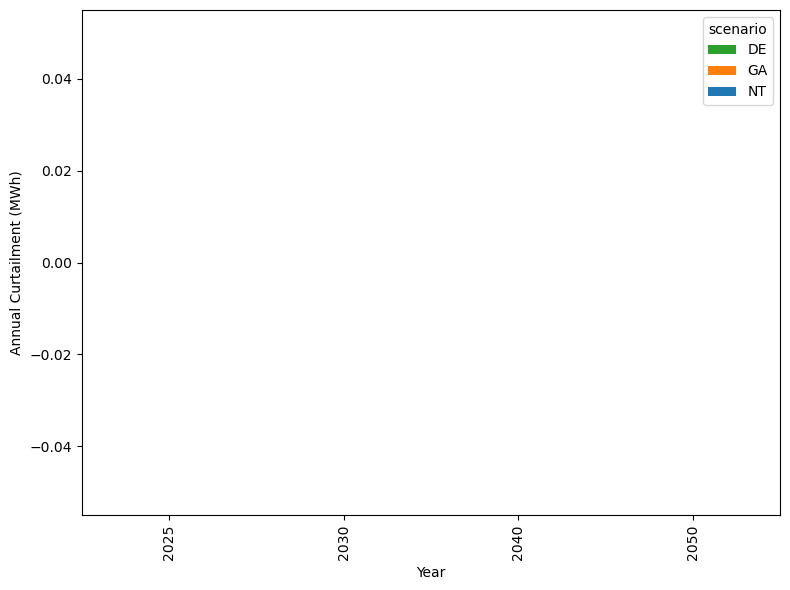

Annual Load Shedding by Year and Scenario


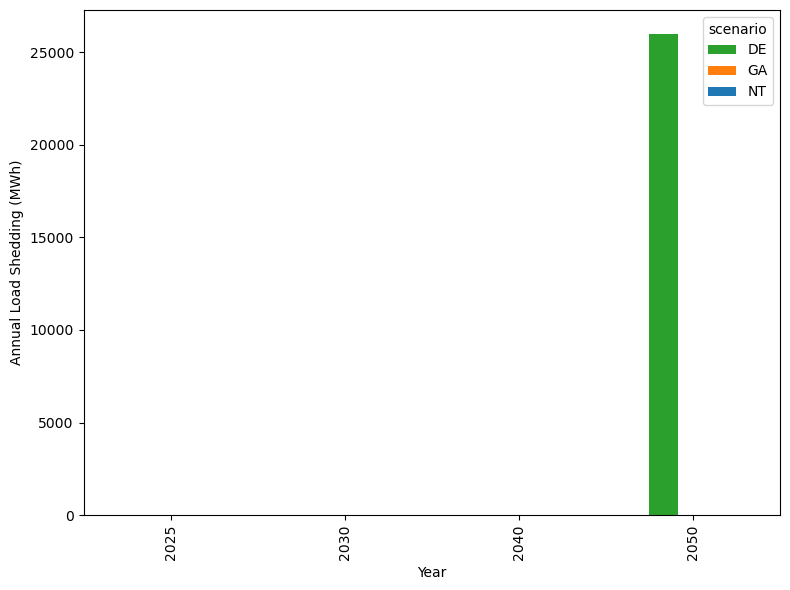

In [64]:
analytics.plot_curtailment_by_scenario(
    curtailment, week_weights, savefolder=figures_folder
)


analytics.plot_load_shedding_by_scenario(
    load_shedding, week_weights, savefolder=figures_folder
)

In [65]:
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT             0.000000          0.0        0.000000e+00   
2030 NT             0.000000          0.0        0.000000e+00   
2040 DE             0.000000          0.0        0.000000e+00   
     GA             0.000000          0.0        0.000000e+00   
     NT             0.000000          0.0        0.000000e+00   
2050 DE         25969.606288          0.0        1.649070e+08   
     GA             0.000000          0.0        0.000000e+00   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

## Macro analysis

In [66]:
if SAVE_FIGURES:
    macro_save_folder = os.path.join(figures_folder, "macro")
    if not os.path.exists(macro_save_folder):
        os.makedirs(macro_save_folder)
else:
    macro_save_folder = None
if SAVE_TABLES:
    macro_save_table_folder = os.path.join(tables_folder, "macro")
    if not os.path.exists(macro_save_table_folder):
        os.makedirs(macro_save_table_folder)
else:
    macro_save_table_folder = None

In [67]:
system_summary = analytics.make_system_summary_table(
    generation,
    generators,
    week_weights,
    scenarios,
    scenario_probabilities,
    CO2_price,
    savefolder=macro_save_folder,
)

In [68]:
system_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout,total_production,total_co2_emissions,total_co2_emission_cost,total_production_cost,total_production_cost_with_emission,total_cost
year,,,,,,,,,,,
2025,48228.204285,35930.681544,51,41,3.972938e+09,2.821796e+08,2.512532e+07,4.020051e+09,4.895954e+09,8.916005e+09,1.288894e+10
2030,48228.204285,32977.401815,51,35,3.555738e+09,3.007564e+08,2.073013e+07,3.316821e+09,4.034737e+09,7.351557e+09,1.090730e+10
2040,48228.204285,27597.218960,51,27,2.941959e+09,3.590029e+08,2.394706e+07,3.831529e+09,4.663273e+09,8.494802e+09,1.143676e+10
2050,48228.204285,9179.564159,51,13,5.774627e+08,3.829315e+08,2.538094e+07,4.060951e+09,4.913495e+09,8.974446e+09,9.551909e+09


In [69]:
if len(batteries) > 0:
    battery_summary = analytics.make_battery_system_summary(
        batteries,
        battery_discharging,
        week_weights,
        scenarios,
        scenario_probabilities,
        savefolder=tables_folder,
    )
else:
    # Dummy columns
    columns = ["num_buildout", "capacity", "investment_cost", "cycles_per_year"]

    # Create the DataFrame with NaNs
    empty_df = pd.DataFrame(index=years, columns=columns)
    empty_df.index.name = "year"
    battery_summary = empty_df

In [70]:
battery_summary

,num_buildout,capacity,investment_cost,cycles_per_year
year,,,,
2025,NaN,NaN,NaN,NaN
2030,NaN,NaN,NaN,NaN
2040,NaN,NaN,NaN,NaN
2050,NaN,NaN,NaN,NaN


In [71]:
branch_summary = analytics.make_branch_buildout_summary(branches, tables_folder)
yearly_system_cost_table = analytics.make_yearly_system_costs_table(
    generation, generators, week_weights, CO2_price, savefolder=tables_folder
)
curtailment_and_load_shedding_table = (
    analytics.make_curtailment_load_shedding_cost_table(
        curtailment, load_shedding, week_weights, CC, VOLL, savefolder=tables_folder
    )
)

Branch buildout summary by year:
Yearly system metrics by year and scenario:


In [72]:
branch_summary

,potential_capacity,new_capacity,number_possible_buildouts,number_actual_buildouts,cost_of_buildout
year,,,,,
2025,95000,18733.823892,19,5,3.192813e+08
2030,95000,11935.560098,19,3,2.037555e+08
2040,95000,0.000000,19,0,0.000000e+00
2050,95000,0.000000,19,0,0.000000e+00


In [73]:
yearly_system_cost_table

production  co2_emission  co2_emission_cost  production_cost  \
year scenario                                                                   
2025 NT        2.821796e+08  2.512532e+07       4.020051e+09     4.895954e+09   
2030 NT        3.007564e+08  2.073013e+07       3.316821e+09     4.034737e+09   
2040 DE        3.759161e+08  2.667864e+07       4.268582e+09     5.193243e+09   
     GA        3.341147e+08  1.998322e+07       3.197315e+09     3.890476e+09   
     NT        3.669779e+08  2.517932e+07       4.028691e+09     4.906100e+09   
2050 DE        4.060141e+08  2.924673e+07       4.679476e+09     5.635269e+09   
     GA        3.598488e+08  2.151516e+07       3.442426e+09     4.191721e+09   

               production_cost_with_emission  
year scenario                                 
2025 NT                         8.916005e+09  
2030 NT                         7.351557e+09  
2040 DE                         9.461825e+09  
     GA                         7.087791e+09  
     NT                         8.934790e+09  
2050 DE                         1.031475e+10  
     GA                         7.634147e+09

In [74]:
curtailment_and_load_shedding_table

load_shedding  curtailment  load_shedding_cost  \
year scenario                                                   
2025 NT             0.000000          0.0        0.000000e+00   
2030 NT             0.000000          0.0        0.000000e+00   
2040 DE             0.000000          0.0        0.000000e+00   
     GA             0.000000          0.0        0.000000e+00   
     NT             0.000000          0.0        0.000000e+00   
2050 DE         25969.606288          0.0        1.649070e+08   
     GA             0.000000          0.0        0.000000e+00   

               curtailment_cost  
year scenario                    
2025 NT                     0.0  
2030 NT                     0.0  
2040 DE                     0.0  
     GA                     0.0  
     NT                     0.0  
2050 DE                     0.0  
     GA                     0.0

Annual System Costs (average across scenarios)


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:3538: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0)


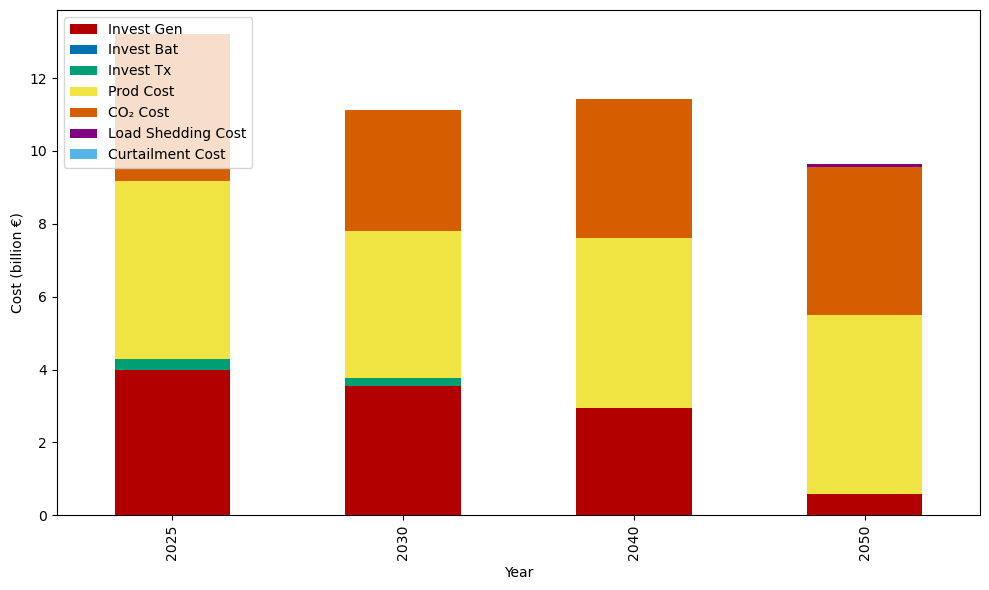

Annual System Costs by Scenario


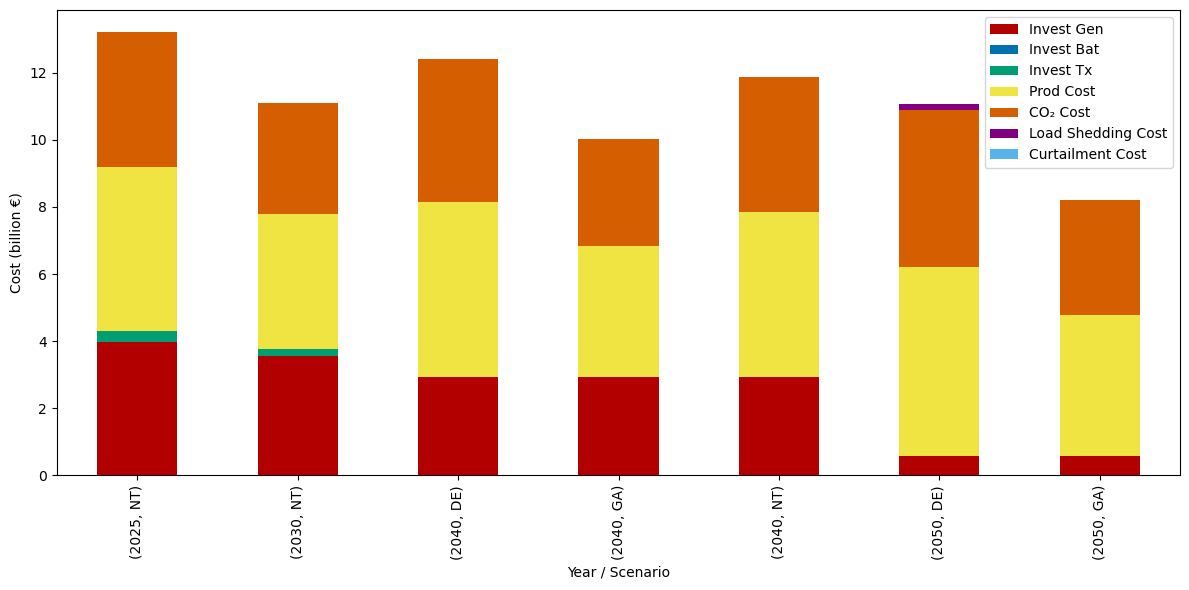

In [75]:
analytics.plot_yearly_costs_stacked_avg(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)
analytics.plot_yearly_costs_stacked_by_scenario(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    savefolder=macro_save_folder,
)

In [76]:
total_system_cost = analytics.compute_total_system_cost(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
total_system_cost

Total system cost by year:


c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\src\analytics.py:3650: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  battery_investment = battery_summary["investment_cost"].fillna(0)


,AIC,expected_OC,total_cost
year,,,
2025,4.292220e+09,8.916005e+09,1.320822e+10
2030,3.759494e+09,7.351557e+09,1.111105e+10
2040,2.941959e+09,8.494802e+09,1.143676e+10
2050,5.774627e+08,9.056899e+09,9.634362e+09


In [77]:
assert (
    abs(total_system_cost["total_cost"].sum() - model_info["Objective Value"][0]) < 1000
), f"Mismatch in total system cost: {total_system_cost['total_cost'].sum():,.0f} vs {model_info['Objective Value'][0]:,.0f}"

In [78]:
mega_table = analytics.make_mega_cost_table(
    system_summary,
    battery_summary,
    branch_summary,
    yearly_system_cost_table,
    curtailment_and_load_shedding_table,
    scenarios,
    scenario_probabilities,
    savefolder=macro_save_table_folder,
)
mega_table

Invest Gen  Invest Bat     Invest Tx  Production Cost  \
year scenario                                                            
2025 NT        3.972938e+09         NaN  3.192813e+08     4.895954e+09   
2030 NT        3.555738e+09         NaN  2.037555e+08     4.034737e+09   
2040 DE        2.941959e+09         NaN  0.000000e+00     5.193243e+09   
     GA        2.941959e+09         NaN  0.000000e+00     3.890476e+09   
     NT        2.941959e+09         NaN  0.000000e+00     4.906100e+09   
2050 DE        5.774627e+08         NaN  0.000000e+00     5.635269e+09   
     GA        5.774627e+08         NaN  0.000000e+00     4.191721e+09   
All  All       1.104810e+10         0.0  5.230369e+08     1.850746e+10   

               CO2 Emission Cost  Load Shedding Cost  Curtailment Cost  \
year scenario                                                            
2025 NT             4.020051e+09        0.000000e+00               0.0   
2030 NT             3.316821e+09        0.000000e+00               0.0   
2040 DE             4.268582e+09        0.000000e+00               0.0   
     GA             3.197315e+09        0.000000e+00               0.0   
     NT             4.028691e+09        0.000000e+00               0.0   
2050 DE             4.679476e+09        1.649070e+08               0.0   
     GA             3.442426e+09        0.000000e+00               0.0   
All  All            1.522935e+10        8.245350e+07               0.0   

               Prod+CO2 Cost   Total CapEx    Total OpEx    Total Cost  
year scenario                                                           
2025 NT         8.916005e+09  4.292220e+09  8.916005e+09  1.320822e+10  
2030 NT         7.351557e+09  3.759494e+09  7.351557e+09  1.111105e+10  
2040 DE         9.461825e+09  2.941959e+09  9.461825e+09  1.240378e+10  
     GA         7.087791e+09  2.941959e+09  7.087791e+09  1.002975e+10  
     NT         8.934790e+09  2.941959e+09  8.934790e+09  1.187675e+10  
2050 DE         1.031475e+10  5.774627e+08  1.047965e+10  1.105711e+10  
     GA         7.634147e+09  5.774627e+08  7.634147e+09  8.211610e+09  
All  All        3.373681e+10  1.157114e+10  3.381926e+10  4.539040e+10

In [79]:
generators

,,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name,extendable,extension_potential,new_capacity,cum_new_capacity,cum_extension_potential,total_capacity
year,generator,,,,,,,,,,,,,,
2025,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99027.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,1712.650000,3425.300000
2030,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99017.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,3425.300000,3425.300000
2040,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,99007.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,5137.950000,3425.300000
2050,ES1 0 CCGT,ES1 0,CCGT,3425.300000,38.855172,98997.729293,0.20,#b20101,Combined-Cycle Gas,True,1712.650000,0.000000,0.000000,6850.600000,3425.300000
2025,ES1 0 coal,ES1 0,coal,1068.524933,28.196970,349976.553630,0.34,#707070,Coal,True,534.262466,0.000000,0.000000,534.262466,1068.524933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,PT1 1 ror,PT1 1,ror,269.600000,0.000000,299110.224929,0.00,#4adbc8,Run of River,True,134.800000,0.000000,404.400000,539.200000,674.000000
2025,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35602.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,324.036799,324.036799,972.110398
2030,PT1 1 solar,PT1 1,solar,648.073599,0.010000,35592.071244,0.00,#f9d002,Solar,True,324.036799,324.036799,648.073599,648.073599,1296.147198


In [80]:
# End  by saving the extended generators, transmission lines, and batteries tables to and extended tables folder
if tables_folder:
    # Create the extended tables folder if it doesn't exist
    extended_tables_folder = os.path.join(tables_folder, "extended_tables")
    os.makedirs(extended_tables_folder, exist_ok=True)
    generators.to_csv(
        os.path.join(extended_tables_folder, "extended_generators.csv"), index=True
    )
    branches.to_csv(
        os.path.join(extended_tables_folder, "extended_branches.csv"), index=True
    )
    batteries.to_csv(
        os.path.join(extended_tables_folder, "extended_batteries.csv"), index=True
    )

# Dual Variables Analysis

In [81]:
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))
    print("------------------------")

battery_charge_new_max_duals



,,,,,dual_value
battery,scenario,year,week,hour,


------------------------
battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


------------------------
battery_discharge_new_max_duals



...

------------------------
load_shedding_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 9    0            0.0
                         1            0.0

------------------------
power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 9    0      70.420507
                         1      70.420507

------------------------


In [82]:
# Build a DataFrame of scenario probabilities (p_{ω,y})
prob_rows = []
for year_str, scen_list in scenarios.items():
    year = int(year_str)
    probs = scenario_probabilities[year_str]
    for scen, p in zip(scen_list, probs):
        prob_rows.append({"year": year, "scenario": scen, "p": p})
prob_df = pd.DataFrame(prob_rows).set_index(["year", "scenario"])

prob_df

p
year scenario          
2025 NT        1.000000
2030 NT        1.000000
2040 NT        0.333333
     GA        0.333333
     DE        0.333333
2050 GA        0.500000
     DE        0.500000

In [83]:
# Loop through duals and apply 1/p weighting where appropriate
for key, df in dual_variables.items():
    print(key)
    print()
    display(df.head(2))

    # Only apply to duals that vary by scenario
    if "scenario" in df.index.names:
        temp = df.reset_index().merge(prob_df, on=["year", "scenario"], how="left")
        # Compute 1/p weight
        temp["weight"] = 1.0 / temp["p"]
        # Apply weight to the dual values
        temp["dual_value"] = temp["dual_value"] * temp["weight"]

        # Reconstruct a weighted-dual Series with the original index
        weighted = temp.set_index(df.index.names)
        # Display the first two rows
        display(weighted.head(2))
        dual_variables[key] = weighted

battery_charge_new_max_duals



,,,,,dual_value
battery,scenario,year,week,hour,


,,,,,dual_value,p,weight
battery,scenario,year,week,hour,,,


battery_charge_old_duals



,,,,,,dual_value
battery,bound,scenario,year,week,hour,


...

dual_value
node  scenario year week hour            
ES1 0 NT       2025 9    0            0.0
                         1            0.0

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 9    0            0.0  1.0     1.0
                         1            0.0  1.0     1.0

power_balance_duals



dual_value
node  scenario year week hour            
ES1 0 NT       2025 9    0      70.420507
                         1      70.420507

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 9    0      70.420507  1.0     1.0
                         1      70.420507  1.0     1.0

In [84]:
# dual variables
battery_charge_new_max_duals = dual_variables["battery_charge_new_max_duals"]
battery_charge_old_duals = dual_variables["battery_charge_old_duals"]
battery_discharge_new_max_duals = dual_variables["battery_discharge_new_max_duals"]
battery_discharge_old_duals = dual_variables["battery_discharge_old_duals"]
branch_extension_duals = dual_variables["branch_extension_duals"]
branch_flow_old_duals_min = dual_variables["branch_flow_old_duals_min"]
branch_flow_old_duals_max = dual_variables["branch_flow_old_duals_max"]
branch_flow_new_duals_min = dual_variables["branch_flow_new_duals_min"]
branch_flow_new_duals_max = dual_variables["branch_flow_new_duals_max"]
emissions_duals = dual_variables["emissions_duals"]
gen_extension_duals = dual_variables["gen_extension_duals"]
gen_output_new_duals = dual_variables["gen_output_new_duals"]
gen_output_old_duals = dual_variables["gen_output_old_duals"]
load_shedding_duals = dual_variables["load_shedding_duals"]
power_balance_duals = dual_variables["power_balance_duals"]

### Power Balance Duals

In [85]:
node_to_city = {
    "ES1 0": "Murcia",
    "ES1 1": "Bilbao",
    "ES1 2": "Zaragoza",
    "ES1 3": "Seville",
    "ES1 4": "Lugo",
    "ES1 5": "Madrid",
    "ES1 6": "Valencia",
    "ES1 7": "Salamanca",
    "ES1 8": "Barcelona",
    "PT1 0": "Porto",
    "PT1 1": "Lisbon",
}

In [86]:
if SAVE_FIGURES:
    # Create the figures folder if it doesn't exist
    dual_folder = os.path.join(RESULTS_FOLDER, "duals")
    os.makedirs(dual_folder, exist_ok=True)
else:
    dual_folder = None
if SAVE_TABLES:
    # Create the tables folder if it doesn't exist
    dual_tables_folder = os.path.join(tables_folder, "duals")
    os.makedirs(dual_tables_folder, exist_ok=True)
else:
    dual_tables_folder = None

In [87]:
lmp_table = analytics.make_nodal_price_table(
    power_balance_duals, savefolder=dual_tables_folder
)

lmp_table

Annual Average Locational Marginal Prices by Node


node               ES1 0      ES1 1      ES1 2      ES1 3      ES1 4  \
year scenario                                                          
2025 NT        63.813409  62.863418  63.601235  63.007753  63.521261   
2030 NT        56.451957  56.191992  56.554226  56.372284  56.833634   
2040 DE        58.022181  57.888929  58.267871  57.987691  58.460842   
     GA        53.033147  52.748606  53.163884  52.860540  53.296055   
     NT        56.692745  56.514920  56.908210  56.619062  57.081740   
2050 DE        76.221264  76.574609  76.850075  76.615102  77.239688   
     GA        53.236660  53.083494  53.491410  53.176938  53.616780   

node               ES1 5      ES1 6      ES1 7      ES1 8      PT1 0  \
year scenario                                                          
2025 NT        63.695115  64.378362  64.293626  64.208442  64.050203   
2030 NT        56.987258  57.245247  57.522739  57.094154  57.505868   
2040 DE        58.618404  58.979830  59.169212  58.824159  59.079416   
     GA        53.437204  53.813479  53.939326  53.671444  53.853373   
     NT        57.235597  57.603556  57.773412  57.451518  57.681917   
2050 DE        77.446733  77.789086  78.174461  77.583769  78.138202   
     GA        53.756483  54.145007  54.261606  54.002097  54.203151   

node               PT1 1  
year scenario             
2025 NT        64.740341  
2030 NT        58.047610  
2040 DE        59.518504  
     GA        54.248972  
     NT        58.107387  
2050 DE        78.761440  
     GA        54.611024

In [88]:
annual_lmp_table = analytics.make_annual_lmp_table(
    power_balance_duals, savefolder=dual_tables_folder
)
annual_lmp_table

scenario,DE,GA,NT,Average
year,,,,
2025,NaN,NaN,63.833924,63.833924
2030,NaN,NaN,56.982452,56.982452
2040,58.619731,53.460548,57.242733,56.441004
2050,77.399494,53.780423,NaN,65.589958


Average LMP by Year and Scenario (±1 std)


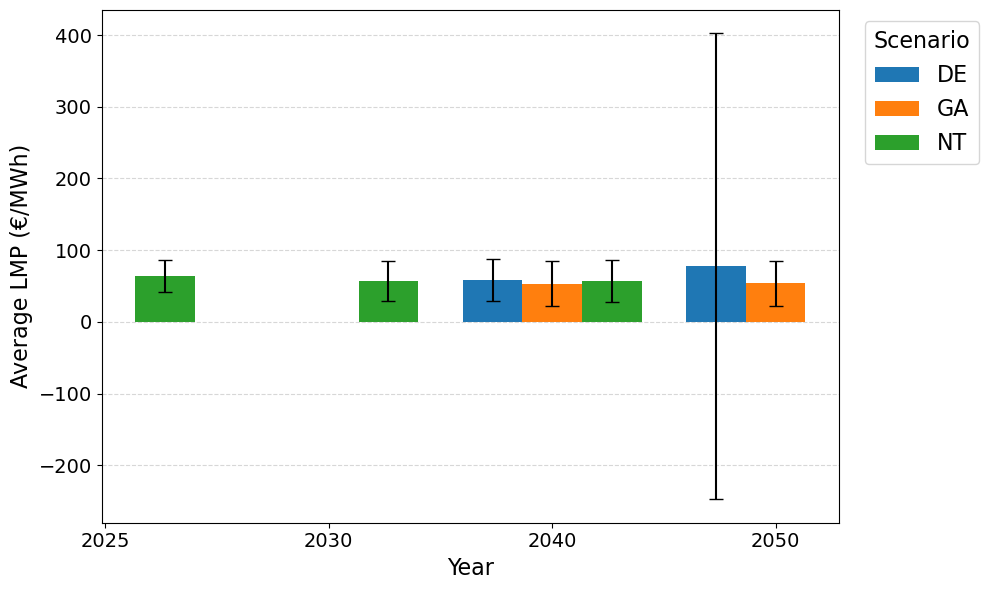

In [89]:
analytics.plot_annual_lmp_by_scenario(power_balance_duals, savefolder=dual_folder)

Average LMP by Year and Scenario


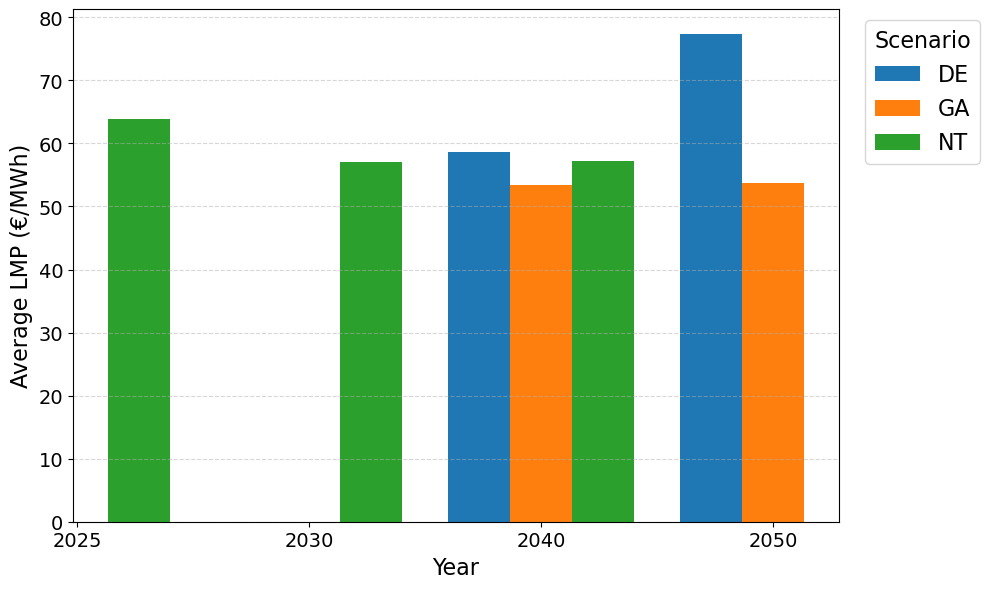

In [90]:
analytics.plot_annual_lmp_by_scenario_simple(
    power_balance_duals, savefolder=dual_folder
)

Average LMP by Year and Scenario (line chart)


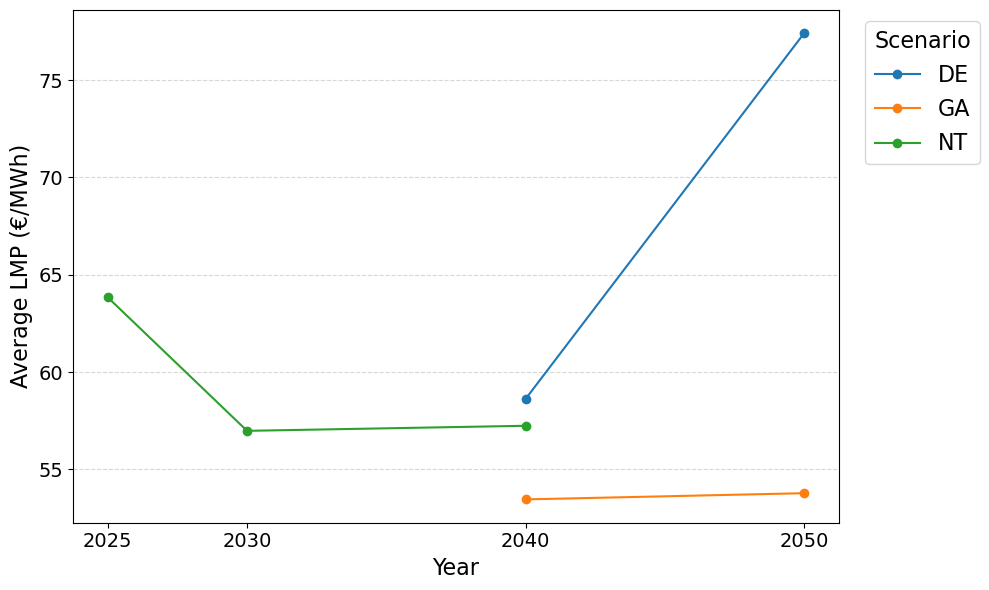

In [91]:
analytics.plot_annual_lmp_by_scenario_line(power_balance_duals, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (with markers)


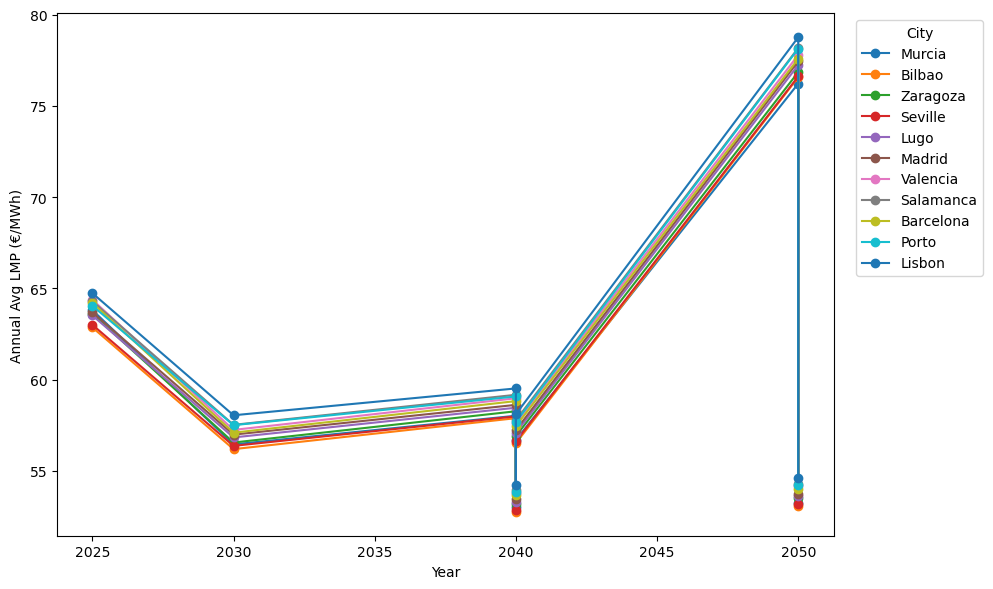

In [92]:
analytics.plot_nodal_price_evolution_with_markers(lmp_table, savefolder=dual_folder)

Annual Average Locational Marginal Prices by City (grouped bar)


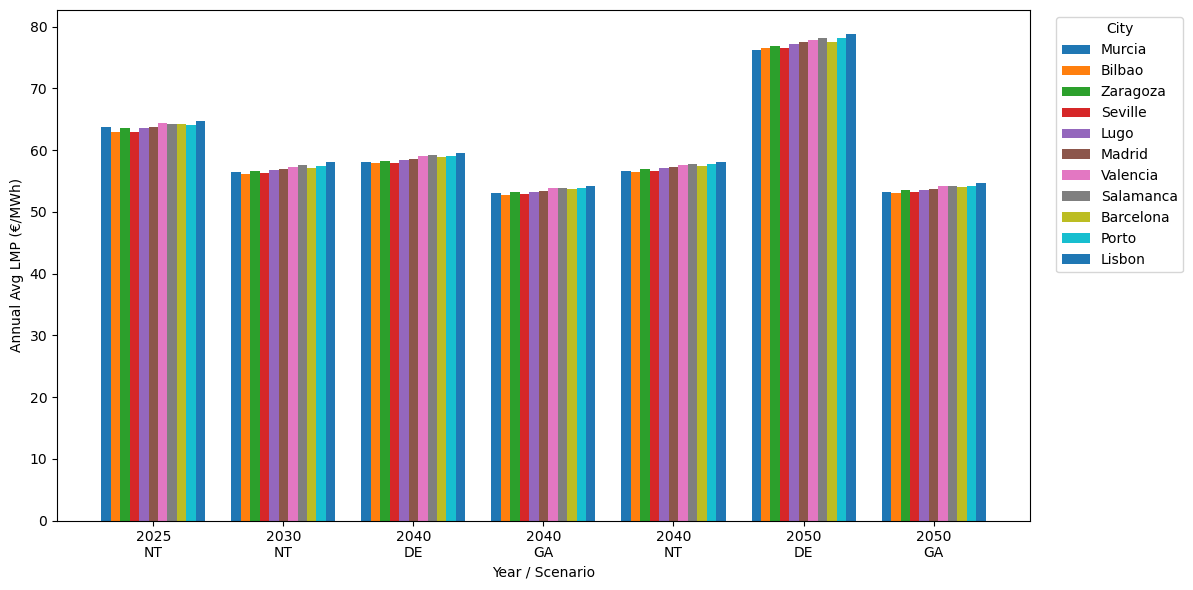

In [93]:
analytics.plot_nodal_price_grouped_bar(
    lmp_table, node_to_city=node_to_city, savefolder=dual_folder
)

In [94]:
branch_extension_duals = branch_extension_duals.rename_axis(index={"branch": "line"})
branch_extension_duals

dual_value
line year              
88   2025 -20290.567074
     2030  -3721.835566
     2040      0.000000
     2050      0.000000
89   2025      0.000000
...                 ...
107  2050      0.000000
219  2025      0.000000
     2030      0.000000
     2040      0.000000
     2050      0.000000

[76 rows x 1 columns]

In [95]:
generators["production_cost"] = (
    generators["marginal_cost"] + generators["co2_emissions"] * CO2_price
)
generators.groupby("carrier")["production_cost"].mean().sort_values(ascending=True)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
CCGT          72.520397
coal          82.596970
Name: production_cost, dtype: float64

In [96]:
for year in power_balance_duals.index.get_level_values("year").unique():
    scen_list = (
        power_balance_duals.xs(year, level="year")
        .index.get_level_values("scenario")
        .unique()
    )
    for scen in scen_list:
        sub = power_balance_duals.xs((scen, year), level=("scenario", "year"))
        vals = sub["dual_value"].values
        print(f"Year: {year}, Scenario: {scen}, max dual: {vals.max()}")

Year: 2025, Scenario: NT, max dual: 112.50704379100596
Year: 2030, Scenario: NT, max dual: 87.87870928672136
Year: 2040, Scenario: NT, max dual: 218.51358556007392
Year: 2040, Scenario: GA, max dual: 216.82479796794152
Year: 2040, Scenario: DE, max dual: 241.84505000399412
Year: 2050, Scenario: GA, max dual: 222.4307339679938
Year: 2050, Scenario: DE, max dual: 6350.0


In [97]:
freqs = analytics.compute_lmp_bucket_frequencies(
    power_balance_duals, generators, dual_tables_folder
)


freqs

LMP Bucket Frequencies


,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,0,0.000000
neg_thermal,-90.856667,-65.268358,0,0.000000
gap_neg_thermal_neg_wind,-65.268358,-0.016500,0,0.000000
neg_wind,-0.016500,-0.013500,0,0.000000
gap_neg_wind_neg_solar,-0.013500,-0.011000,0,0.000000
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000


LMP Bucket Absolute Frequencies


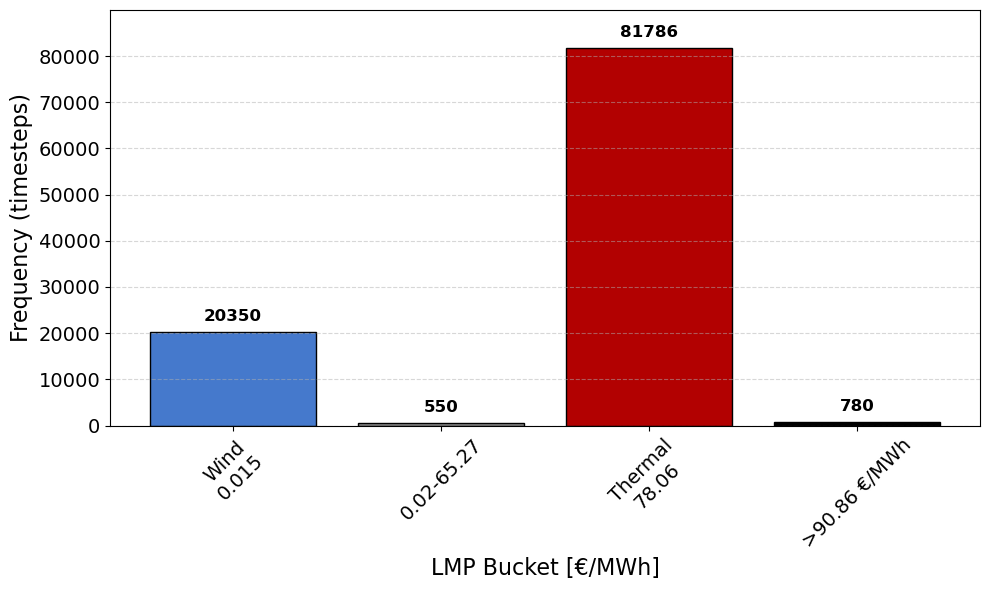

In [98]:
analytics.plot_lmp_bucket_frequencies(freqs, savefolder=dual_folder)

In [99]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,0,0.000000
neg_thermal,-90.856667,-65.268358,0,0.000000
gap_neg_thermal_neg_wind,-65.268358,-0.016500,0,0.000000
neg_wind,-0.016500,-0.013500,0,0.000000
gap_neg_wind_neg_solar,-0.013500,-0.011000,0,0.000000
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000


LMP Bucket Relative Frequencies (%)


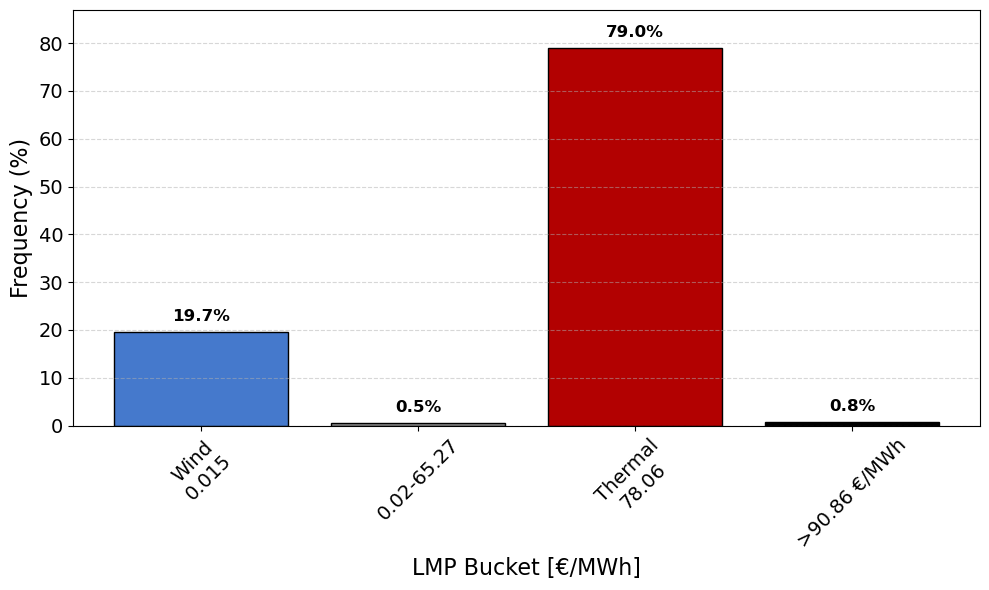

In [100]:
analytics.plot_lmp_bucket_percentages(freqs, savefolder=dual_folder)

In [101]:
for year in power_balance_duals.index.get_level_values("year").unique():
    scen_list = (
        power_balance_duals.xs(year, level="year")
        .index.get_level_values("scenario")
        .unique()
    )
    for scen in scen_list:
        sub = power_balance_duals.xs((scen, year), level=("scenario", "year"))
        vals = sub["dual_value"].values
        print(f"Year: {year}, Scenario: {scen}, max dual: {vals.max()}")

Year: 2025, Scenario: NT, max dual: 112.50704379100596
Year: 2030, Scenario: NT, max dual: 87.87870928672136
Year: 2040, Scenario: NT, max dual: 218.51358556007392
Year: 2040, Scenario: GA, max dual: 216.82479796794152
Year: 2040, Scenario: DE, max dual: 241.84505000399412
Year: 2050, Scenario: GA, max dual: 222.4307339679938
Year: 2050, Scenario: DE, max dual: 6350.0


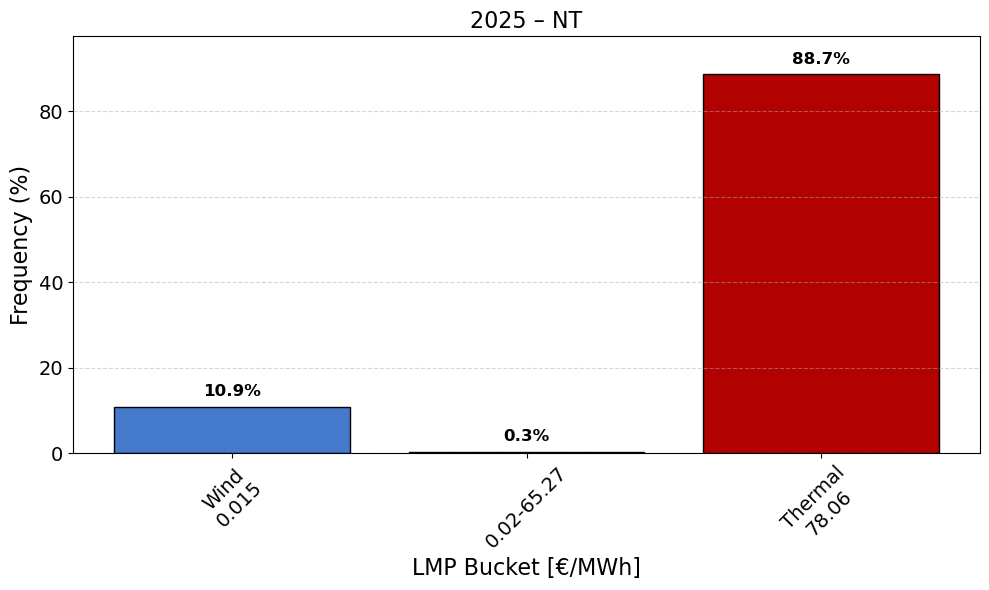

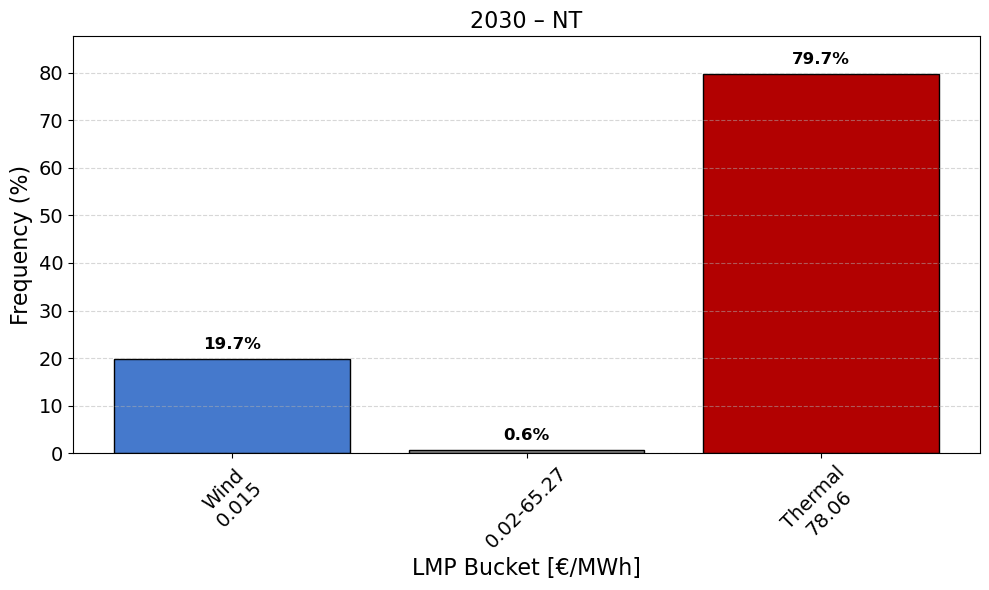

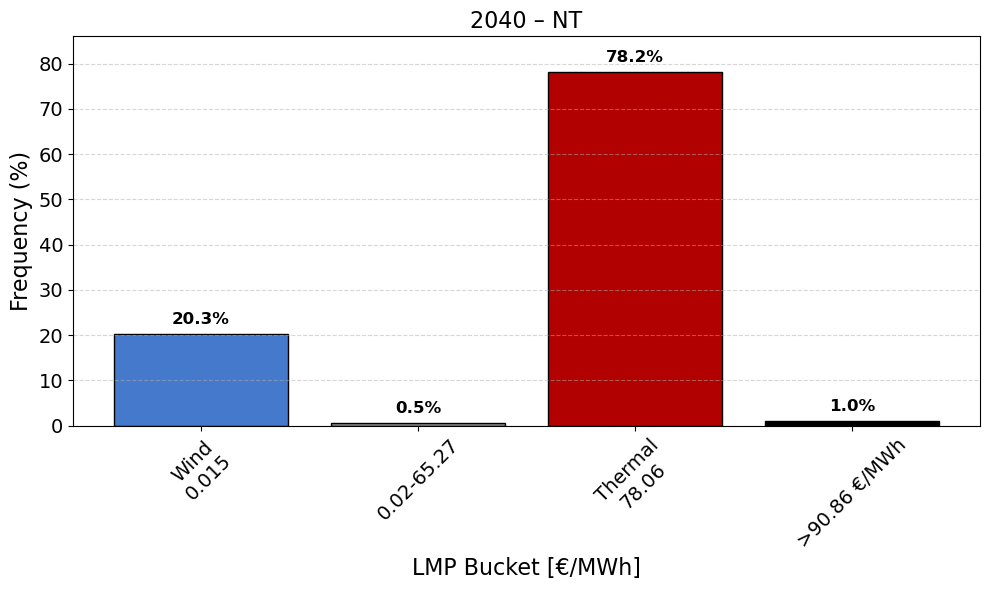

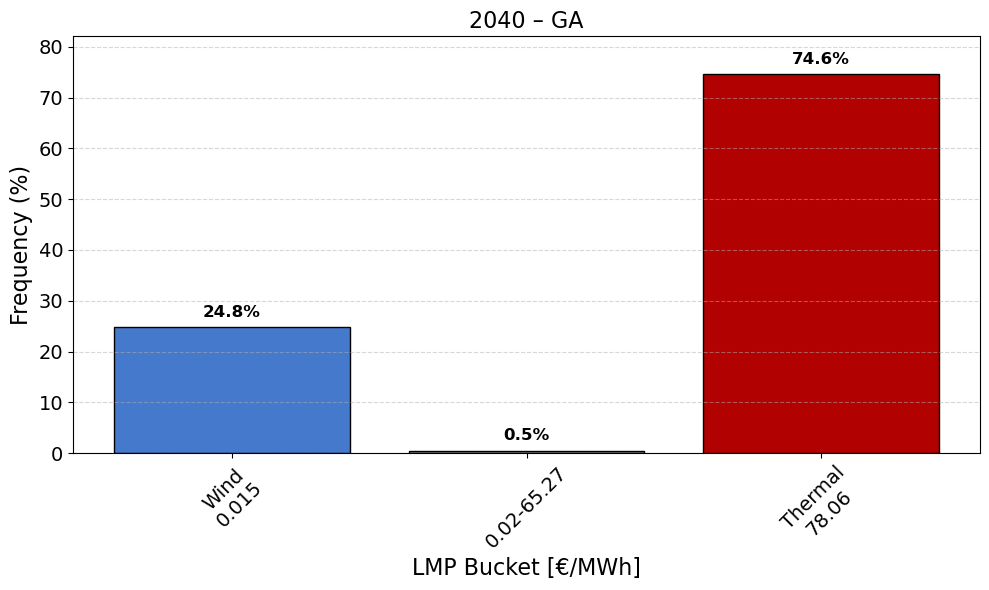

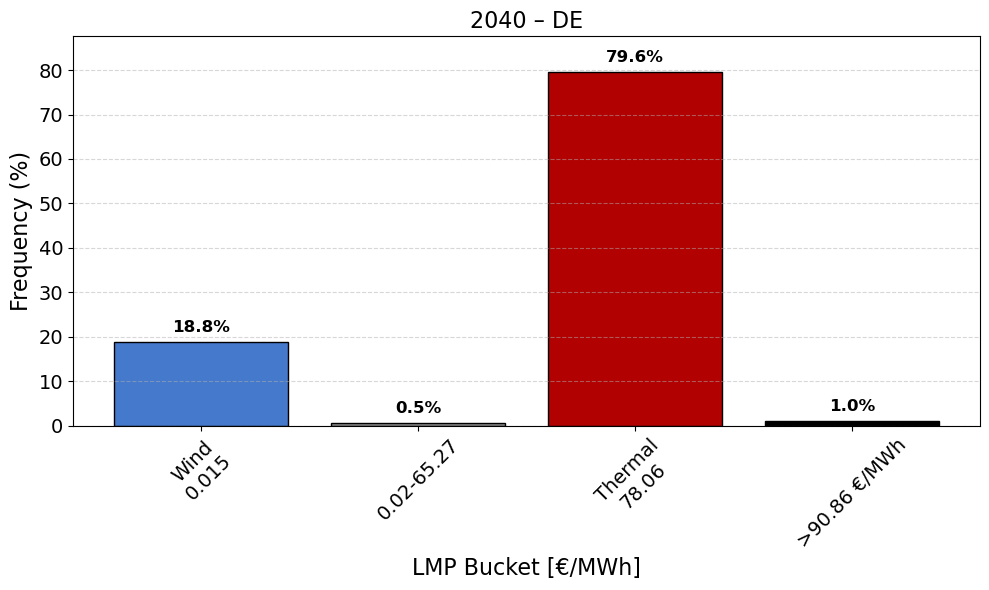

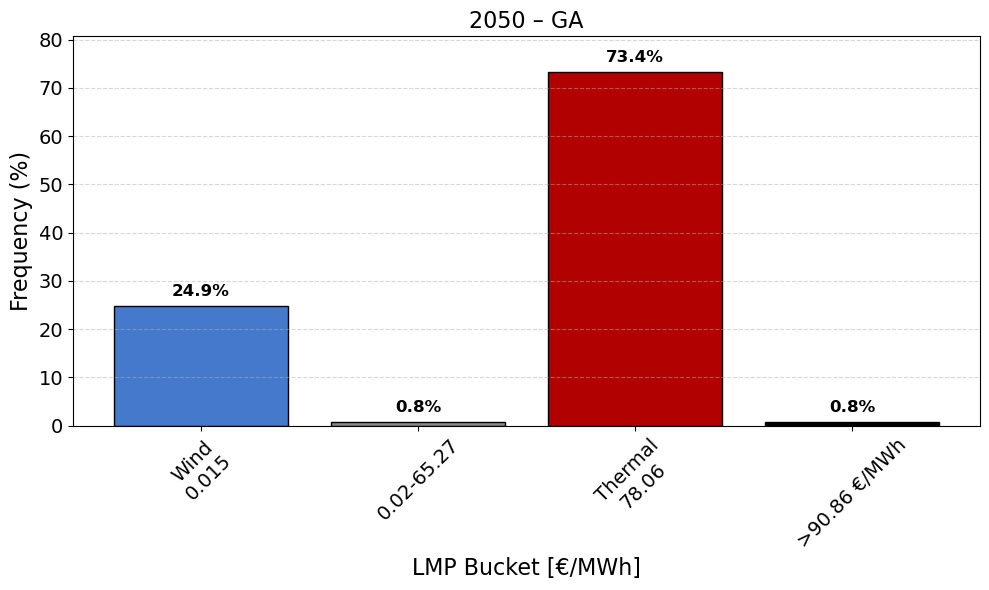

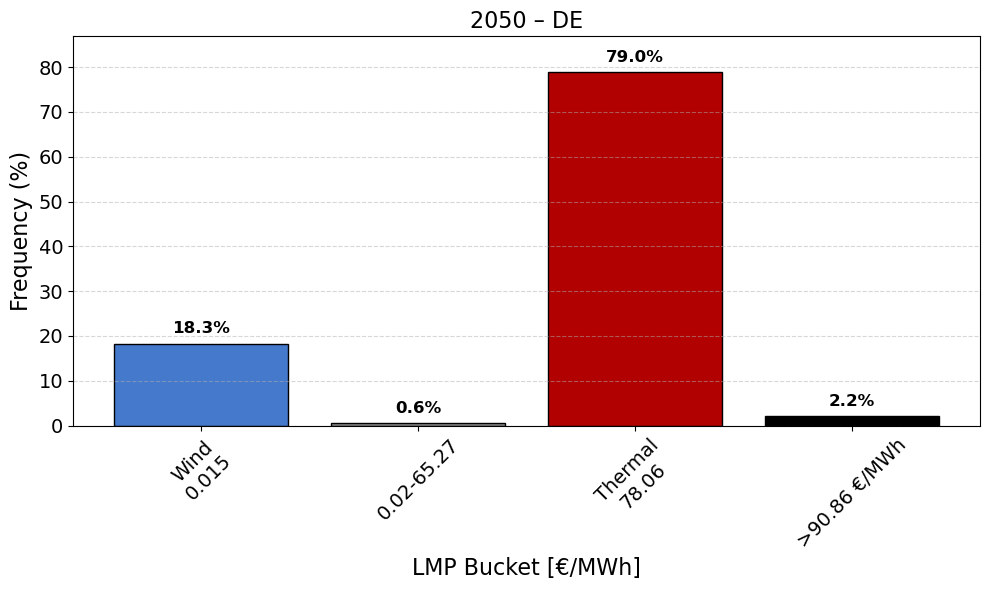

In [102]:
analytics.plot_lmp_bucket_percentages_by_year_scenario(
    power_balance_duals, freqs, savefolder=dual_folder
)

In [103]:
freqs

,lower,upper,absolute,relative_percent
bucket,,,,
curtailment,-110.000000,-90.000000,0,0.000000
neg_thermal,-90.856667,-65.268358,0,0.000000
gap_neg_thermal_neg_wind,-65.268358,-0.016500,0,0.000000
neg_wind,-0.016500,-0.013500,0,0.000000
gap_neg_wind_neg_solar,-0.013500,-0.011000,0,0.000000
neg_solar,-0.011000,-0.009000,0,0.000000
gap_neg_solar_non-binding,-0.009000,-0.000100,0,0.000000
non-binding,-0.000100,0.000100,0,0.000000
gap_non-binding_solar,0.000100,0.009000,0,0.000000


df         year scenario  dual_value
0       2025       NT   70.420507
1       2025       NT   70.420507
2       2025       NT   70.420507
3       2025       NT   70.420507
4       2025       NT   69.719436
...      ...      ...         ...
103483  2050       DE   71.464905
103484  2050       DE   71.460749
103485  2050       DE   71.462827
103486  2050       DE   71.089520
103487  2050       DE   70.696163

[103488 rows x 3 columns]
high         year scenario   dual_value
42      2025       NT   110.955498
43      2025       NT   104.870146
2730    2040       NT   123.961170
2731    2040       NT   116.312054
2802    2040       NT    96.586763
...      ...      ...          ...
103265  2050       DE   396.671672
103312  2050       DE   140.489743
103409  2050       DE   133.319850
103410  2050       DE  6350.000000
103411  2050       DE   122.737066

[780 rows x 3 columns]
scenario   DE   GA   NT
year                   
2025        0    0   23
2040      152   22  143
2050      319  12

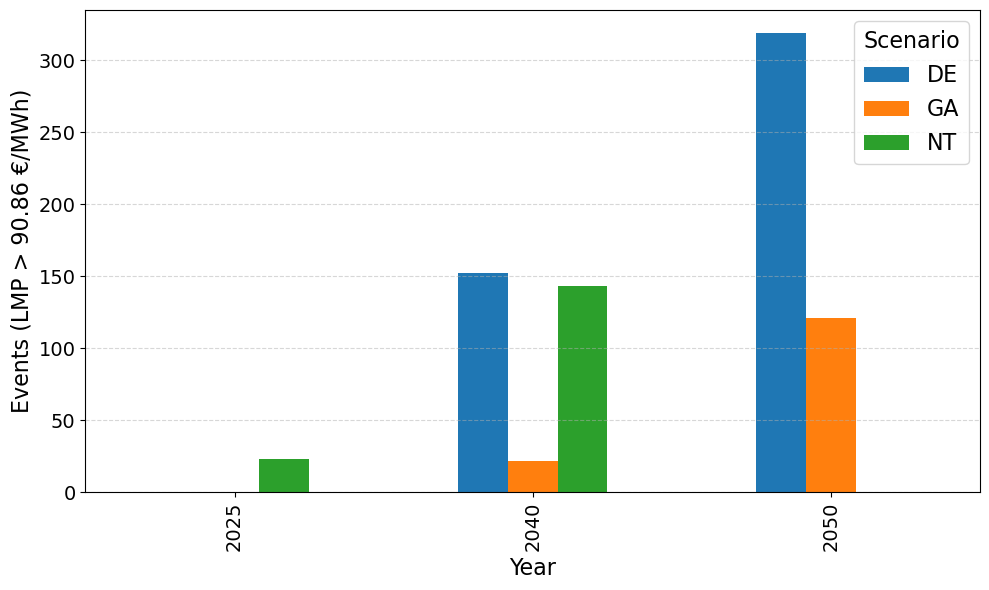

Distribution of LMPs > 90.86 €/MWh


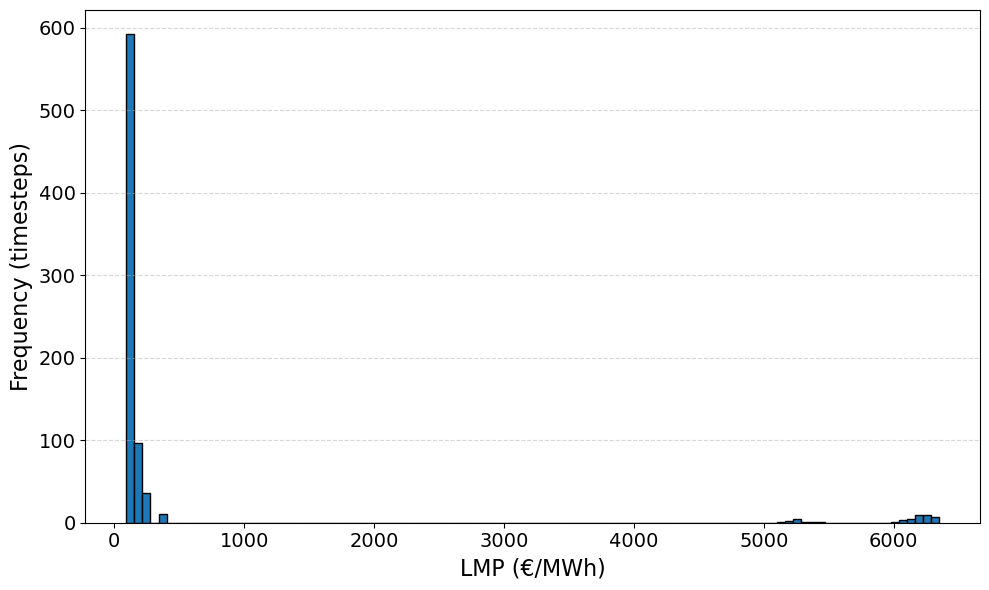

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
49       6233.0       6350.0     15        34.090909          0.014494
48       6116.0       6233.0     13        29.545455          0.012562
40       5180.0       5297.0      7        15.909091          0.006764
47       5999.0       6116.0      5        11.363636          0.004831
41       5297.0       5414.0      2         4.545455          0.001933
42       5414.0       5531.0      1         2.272727          0.000966
39       5063.0       5180.0      1         2.272727          0.000966
34       4478.0       4595.0      0         0.000000          0.000000
27       3659.0       3776.0      0         0.000000          0.000000
28       3776.0       3893.0      0         0.000000          0.000000
Top 5 high-LMP bins by occurrence


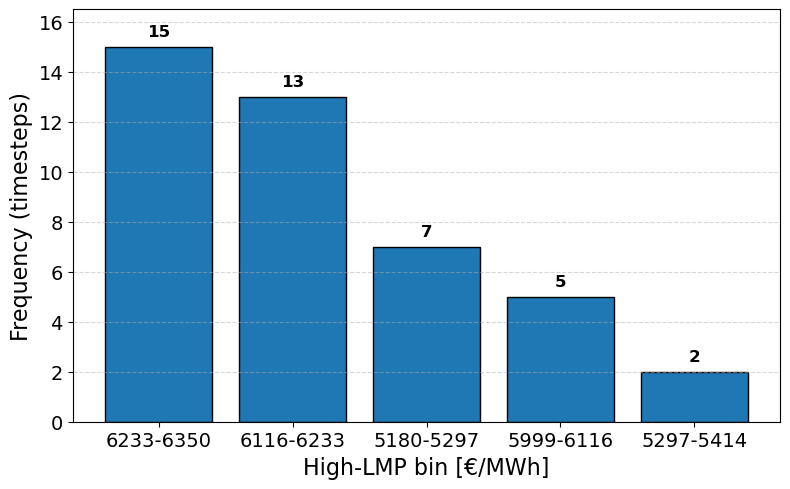

In [104]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:

    cap = freqs.loc[freqs.index != "other", "upper"].max()

    analytics.plot_high_lmp_event_counts(
        power_balance_duals, cap, savefolder=dual_folder
    )

    analytics.plot_high_lmp_distribution(
        power_balance_duals, cap, n_bins=100, savefolder=dual_folder
    )

    high_tbl = analytics.make_high_lmp_frequency_table(
        power_balance_duals, cap=500, n_bins=50, savefolder=dual_tables_folder
    )
    top5 = analytics.get_top_high_lmp_buckets(
        high_tbl, top_n=10, savefolder=dual_tables_folder
    )
    print(top5)
    analytics.plot_top_high_lmp_buckets(high_tbl, top_n=5, savefolder=dual_folder)

    lower_bound  upper_bound  count  percent_of_high  percent_of_total
0        90.856      153.448    592        75.897436          0.572047
1       153.448      216.040     97        12.435897          0.093731
2       216.040      278.631     36         4.615385          0.034787
4       341.222      403.814     11         1.410256          0.010629
98     6224.817     6287.409      9         1.153846          0.008697
97     6162.226     6224.817      9         1.153846          0.008697
99     6287.409     6350.000      7         0.897436          0.006764
82     5223.354     5285.946      5         0.641026          0.004831
96     6099.634     6162.226      4         0.512821          0.003865
95     6037.043     6099.634      3         0.384615          0.002899
Top 6 high-LMP bins by occurrence


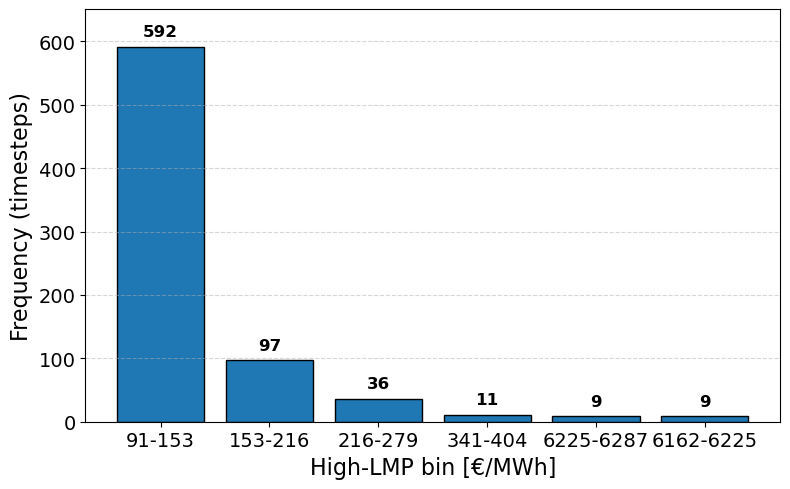

In [105]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    high_tbl = analytics.make_high_lmp_frequency_table(
        power_balance_duals, cap=cap, n_bins=100, savefolder=dual_tables_folder
    )

    top5 = analytics.get_top_high_lmp_buckets(
        high_tbl, top_n=10, savefolder=dual_tables_folder
    )

    print(top5)

    analytics.plot_top_high_lmp_buckets(high_tbl, top_n=6, savefolder=dual_folder)

Detailed histogram for top high-LMP bucket (90.86–153.45 €/MWh)


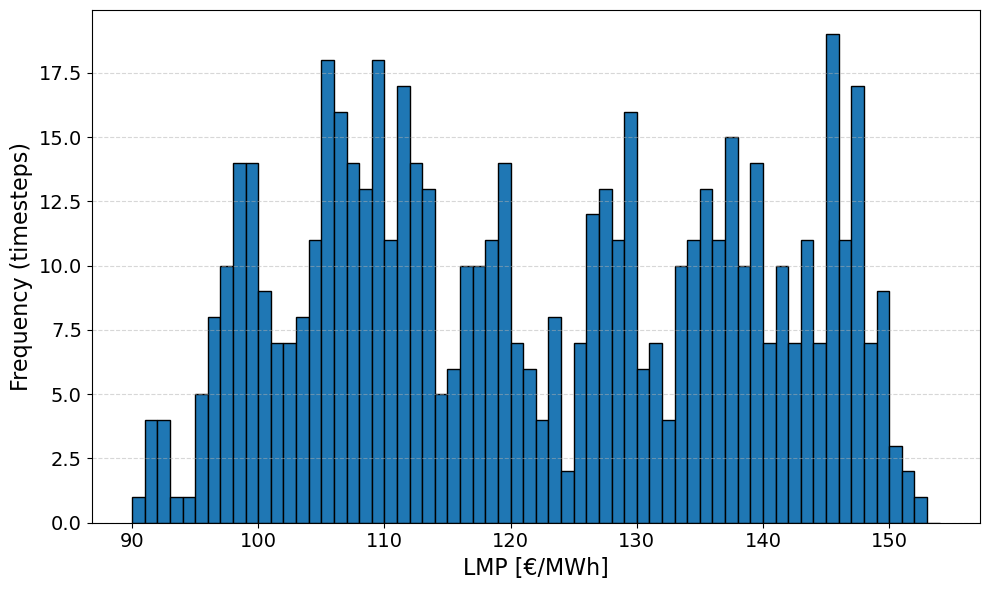

In [106]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    # Assuming you've already built `high_tbl`:

    analytics.plot_top_high_bucket_detail(
        power_balance_duals, high_tbl, width=1.0, savefolder=dual_folder
    )

In [107]:
power_balance_duals

dual_value    p  weight
node  scenario year week hour                         
ES1 0 NT       2025 9    0      70.420507  1.0     1.0
                         1      70.420507  1.0     1.0
                         2      70.420507  1.0     1.0
                         3      70.420507  1.0     1.0
                         4      69.719436  1.0     1.0
...                                   ...  ...     ...
PT1 1 DE       2050 44   163    71.464905  0.5     2.0
                         164    71.460749  0.5     2.0
                         165    71.462827  0.5     2.0
                         166    71.089520  0.5     2.0
                         167    70.696163  0.5     2.0

[103488 rows x 3 columns]

               count_total  count_bucket  percent_bucket_of_total
year scenario                                                    
2025 NT              14784            38                 0.257035
2030 NT              14784            85                 0.574946
2040 DE              14784            76                 0.514069
     GA              14784            72                 0.487013
     NT              14784            75                 0.507305
2050 DE              14784            84                 0.568182
     GA              14784           120                 0.811688
Distribution of LMPs in bucket 'gap_wind_thermal'


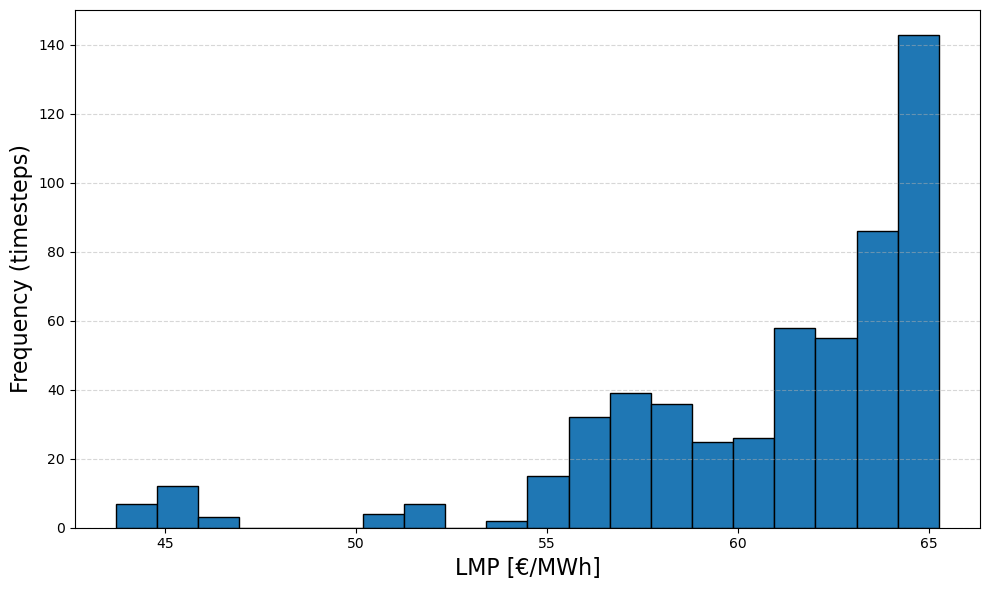

In [108]:
gap_subset = analytics.extract_duals_in_lmp_bucket(
    power_balance_duals, freqs, "gap_wind_thermal"
)
gap_summary = analytics.summarize_gap_duals_by_year_scenario(
    gap_subset, power_balance_duals, savefolder=dual_tables_folder
)
print(gap_summary)
analytics.plot_gap_lmp_distribution(
    gap_subset, "gap_wind_thermal", savefolder=dual_folder
)

LMP ≥ 70 €/MWh: count = 66621 timesteps


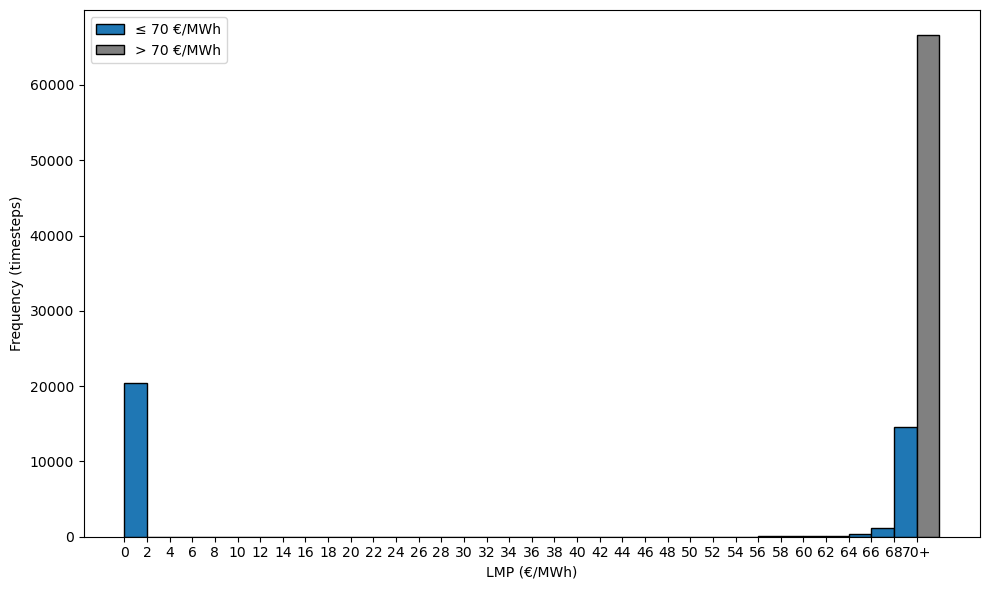

In [109]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    analytics.plot_lmp_histogram_70plus(
        power_balance_duals, cap=70, bin_width=2.0, savefolder=dual_folder
    )

In [110]:
if freqs.loc["other", "absolute"] > 0.01:

    # determine cap from your buckets:
    cap = freqs.loc[freqs.index != "other", "upper"].max()
    freq_table = analytics.make_lmp_frequency_table(
        power_balance_duals, bin_width=1.0, cap=70, savefolder=dual_tables_folder
    )

    with pd.option_context("display.max_rows", None, "display.max_columns", None):

        sorted_freq_table = freq_table.sort_values(by="count", ascending=False)

        display(sorted_freq_table)

,lower_bound,upper_bound,count,percent,count_2025,count_2030,count_2040,count_2050
70,70.0,inf,66621,64.375580,11231,9464,27751,18175
0,0.0,1.0,20372,19.685374,1606,2915,9449,6402
69,69.0,70.0,11400,11.015770,1545,1637,4924,3294
68,68.0,69.0,3211,3.102775,258,500,1405,1048
67,67.0,68.0,831,0.802992,78,107,367,279
66,66.0,67.0,352,0.340136,22,55,169,106
65,65.0,66.0,197,0.190360,10,27,77,83
64,64.0,65.0,112,0.108225,12,13,43,44
63,63.0,64.0,77,0.074405,10,6,25,36
61,61.0,62.0,53,0.051214,2,2,21,28


In [111]:
generators["production_cost"].groupby(generators["carrier"]).mean().sort_values(
    ascending=True
)

carrier
ror            0.000000
solar          0.010000
onwind         0.015000
offwind-ac     0.015000
CCGT          72.520397
coal          82.596970
Name: production_cost, dtype: float64

In [112]:
# plot_top_10_dual_intervals(
#     power_balance_duals, sorted_freq_table, n_bins=10, savefolder=dual_folder
# )
# create_top_10_dual_intervals_tables(
#     power_balance_duals, freq_table, n_bins=10, savefolder=dual_tables_folder
# )

In [113]:
average_duals = power_balance_duals.groupby("year")["dual_value"].mean()
average_duals

year
2025    63.833924
2030    56.982452
2040    56.441004
2050    65.589958
Name: dual_value, dtype: float64

In [114]:
summary_by_carrier = analytics.summarise_extension_status_by_carrier(
    generators, savefolder=generators_save_table_folder
)


summary_by_carrier

Extension status by carrier


extension_status  not extended  partly extended  fully extended
year carrier                                                   
2025 CCGT                    5                0               6
     coal                    5                0               0
     offwind-ac              0                0               9
     onwind                  0                0              11
     ror                     0                0               4
     solar                   0                0              11
2030 CCGT                    7                1               3
     coal                    5                0               0
     offwind-ac              4                0               5
     onwind                  0                0              11
     ror                     0                0               4
     solar                   0                0              11
2040 CCGT                    8                0               3
     coal                    5                0               0
     offwind-ac              6                0               3
     onwind                  3                0               8
     ror                     2                0               2
     solar                   0                0              11
2050 CCGT                   11                0               0
     coal                    5                0               0
     offwind-ac              8                0               1
     onwind                 10                0               1
     ror                     4                0               0
     solar                   0                0              11

In [115]:
# Usage example:
summary_table = analytics.summarize_dual_nonzero_counts(
    dual_variables, dual_tables_folder
)
summary_table

,total_duals,nonzero_duals,percent_nonzero
dual,,,
battery_charge_new_max_duals,0,0,0.000000
battery_charge_old_duals,0,0,0.000000
battery_discharge_new_max_duals,0,0,0.000000
battery_discharge_old_duals,0,0,0.000000
branch_extension_duals,76,4,5.263158
branch_flow_new_duals_max,178752,26156,14.632564
branch_flow_new_duals_min,178752,68351,38.237894
branch_flow_old_duals_max,178752,20449,11.439872
branch_flow_old_duals_min,178752,68403,38.266984


In [116]:
summary = analytics.summarize_duals_by_year_scenario(
    dual_variables, savefolder=dual_tables_folder
)

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", None
):

    display(summary)

total_duals  nonzero_duals  \
dual                      year scenario                               
branch_extension_duals    2025 All                19              2   
                          2030 All                19              2   
                          2040 All                19              0   
                          2050 All                19              0   
branch_flow_new_duals_max 2025 NT              25536           3500   
                          2030 NT              25536           4409   
                          2040 DE              25536           3490   
                               GA              25536           3505   
                               NT              25536           3503   
                          2050 DE              25536           3833   
                               GA              25536           3916   
branch_flow_new_duals_min 2025 NT              25536           9677   
                          2030 NT              25536           9368   
                          2040 DE              25536           9945   
                               GA              25536           9938   
                               NT              25536           9945   
                          2050 DE              25536           9752   
                               GA              25536           9726   
branch_flow_old_duals_max 2025 NT              25536           2557   
                          2030 NT              25536           3355   
                          2040 DE              25536           2833   
                               GA              25536           2874   
                               NT              25536           2848   
                          2050 DE              25536           2966   
                               GA              25536           3016   
branch_flow_old_duals_min 2025 NT              25536           9677   
                          2030 NT              25536           9375   
                          2040 DE              25536           9948   
                               GA              25536           9951   
                               NT              25536           9948   
                          2050 DE              25536           9762   
                               GA              25536           9742   
emissions_duals           2025 NT                  1              0   
                          2030 NT                  1              0   
                          2040 DE                  1              0   
                               GA                  1              0   
                               NT                  1              0   
                          2050 DE                  1              0   
                               GA                  1              0   
gen_extension_duals       2025 All                51             41   
                          2030 All                51             34   
                          2040 All                51             27   
                          2050 All                51             13   
gen_output_new_duals      2025 NT              68544          51149   
                          2030 NT              68544          48150   
                          2040 DE              68544          48822   
                               GA              68544          46725   
                               NT              68544          48362   
                          2050 DE              68544          49228   
                               GA              68544          47041   
gen_output_old_duals      2025 NT              68544          50902   
                          2030 NT              68544          47936   
                          2040 DE              68544          48461   
                               GA              68544          46538   
                               NT              68544          480

In [117]:
nz = analytics.list_nonzero_gen_extension_duals(
    gen_extension_duals, savefolder=dual_tables_folder
)

nz

dual_value
year generator                      
2025 ES1 4 offwind-ac -557835.755231
     ES1 4 onwind     -447982.962507
     PT1 1 ror        -412184.705184
     PT1 0 ror        -405639.124617
     ES1 3 solar      -327564.756389
...                              ...
2050 PT1 0 solar       -43656.934715
     ES1 4 onwind      -41395.383634
     ES1 4 solar       -36462.095345
     ES1 1 solar       -33247.360860
     ES1 4 offwind-ac   -8787.192015

[115 rows x 1 columns]

In [118]:
generators.groupby("carrier")["capital_cost"].mean()

carrier
CCGT           99012.729293
coal          349961.553630
offwind-ac    184181.306769
onwind         96070.888020
ror           299125.224929
solar          35587.071244
Name: capital_cost, dtype: float64